In [ ]:
import random
import numpy as np
import torch
from skimage.exposure import match_histograms

class CuttingSplicingAugmentation:
    """
    Cutting-Splicing Data Augmentation for 2D medical images and segmentation masks.
    Applies horizontal or vertical splitting and recombines patches from other same-class images.
    """
    def __init__(self, apply_prob=0.5):
        self.apply_prob = apply_prob

    def __call__(self, sample_batch):
        images = sample_batch['image']  # shape: [B, 1, H, W]
        labels = sample_batch['label']  # shape: [B, 1, H, W]

        B, C, H, W = images.shape
        augmented_images = images.clone()
        augmented_labels = labels.clone()

        for i in range(B):
            if torch.rand(1).item() > self.apply_prob:
                continue  # Skip augmentation for this sample

            j = random.choice([x for x in range(B) if x != i])

            image_i, label_i = images[i, 0], labels[i, 0]
            image_j, label_j = images[j, 0], labels[j, 0]

            if label_i.sum() == 0 or label_j.sum() == 0:
                continue  # Skip if either is background-only

            # Apply histogram matching
            image_j_matched = match_histograms(image_j.cpu().numpy(), image_i.cpu().numpy(), channel_axis=None)
            image_j_matched = torch.from_numpy(image_j_matched).to(image_j.device)

            # Choose vertical or horizontal cut
            is_horizontal = random.random() > 0.5

            if is_horizontal:
                cut = random.randint(H // 4, 3 * H // 4)
                new_img = torch.cat((image_i[:cut, :], image_j_matched[cut:, :]), dim=0)
                new_lbl = torch.cat((label_i[:cut, :], label_j[cut:, :]), dim=0)
            else:
                cut = random.randint(W // 4, 3 * W // 4)
                new_img = torch.cat((image_i[:, :cut], image_j_matched[:, cut:]), dim=1)
                new_lbl = torch.cat((label_i[:, :cut], label_j[:, cut:]), dim=1)

            augmented_images[i, 0] = new_img
            augmented_labels[i, 0] = new_lbl

        return {
            'image': augmented_images,
            'label': augmented_labels
        }
    

# ----------- Integration Example for Your Training Loop -----------
# After loading your batch using DataLoader
# use this custom collate_fn or augment in your training loop

def collate_fn_with_csda(batch):
    images = torch.stack([torch.tensor(item['image']) for item in batch])[:, None, :, :]
    labels = torch.stack([torch.tensor(item['label']) for item in batch])[:, None, :, :]

    sample_batch = {'image': images, 'label': labels}

    csda = CuttingSplicingAugmentation(apply_prob=0.5)
    augmented_batch = csda(sample_batch)

    return augmented_batch


# Then define your DataLoader like:
# trainloader = DataLoader(db_train, batch_size=batch_size, shuffle=True,
#                          num_workers=4, pin_memory=True, worker_init_fn=worker_init_fn,
#                          collate_fn=collate_fn_with_csda)

# Note: Ensure 'ToTensor()' in your transforms returns float32 normalized image and uint8 mask.


In [ ]:
# import os

# def generate_volume_list(root_dir, output_file='train.list'):
#     volume_paths = []

#     # Level 1: patient folders like 0001, 0002, ...
#     for patient_folder in sorted(os.listdir(root_dir)):
#         patient_path = os.path.join(root_dir, patient_folder)
#         if not os.path.isdir(patient_path):
#             continue

#         # Level 2: volume folders like 11, 14, etc.
#         for volume_folder in sorted(os.listdir(patient_path)):
#             volume_path = os.path.join(patient_path, volume_folder)
#             if not os.path.isdir(volume_path):
#                 continue

#             # Add full path to the volume (e.g., .../0001/11)
#             volume_paths.append(volume_path)

#     # Write all paths to train.list
#     with open(output_file, 'w') as f:
#         for path in volume_paths:
#             f.write(path + '\n')

#     print(f"Saved {len(volume_paths)} volume paths to {output_file}")

# # Example usage:
# converted_data_root = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/Converted_Liver_DaTA'  # <- Change this
# generate_volume_list(converted_data_root)


Saved 310 volume paths to train.list


In [ ]:
# import os
# import random

# def create_train_kits_list(root_dir, output_file='/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/train_kits.list'):
#     # Get full paths of all immediate subdirectories in root_dir
#     volume_paths = [
#         os.path.join(root_dir, d) for d in os.listdir(root_dir)
#         if os.path.isdir(os.path.join(root_dir, d))
#     ]

#     # Shuffle paths with fixed seed
#     random.seed(1337)
#     random.shuffle(volume_paths)

#     # Write to train_kits.list
#     with open(output_file, 'w') as f:
#         for path in volume_paths:
#             f.write(path + '\n')

#     print(f"Saved {len(volume_paths)} volume paths to {output_file}")

# # Example usage:
# create_train_kits_list('/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data') 


Saved 210 volume paths to /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/train_kits.list


In [ ]:
# import os
# import shutil

# input_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas-train-dataset-1.0.1/train/imagesTr"
# label_dir = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/atlas-train-dataset-1.0.1/train/labelsTr"
# output_root = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data"

# os.makedirs(output_root, exist_ok=True)

# for i in range(60):
#     case_id = f"case_{i:05d}"
#     case_dir = os.path.join(output_root, case_id)
#     os.makedirs(case_dir, exist_ok=True)

#     src_img = os.path.join(input_dir, f"im{i}.nii.gz")
#     src_lbl = os.path.join(label_dir, f"lb{i}.nii.gz")
#     dst_img = os.path.join(case_dir, "imaging.nii.gz")
#     dst_lbl = os.path.join(case_dir, "segmentation.nii.gz")

#     shutil.copyfile(src_img, dst_img)
#     shutil.copyfile(src_lbl, dst_lbl)


In [ ]:
# import os

# output_root = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data"
# train_list_path = os.path.join(output_root, "train_atlas.list")
# test_list_path = os.path.join(output_root, "test_atlas.list")

# with open(train_list_path, "w") as train_file, open(test_list_path, "w") as test_file:
#     for i in range(60):
#         case_path = os.path.join(output_root, f"case_{i:05d}")
#         if i < 48:
#             train_file.write(f"{case_path}\n")
#         else:
#             test_file.write(f"{case_path}\n")


In [ ]:
# import os
# import nibabel as nib
# import numpy as np
# import torch
# import torch.nn.functional as F

# data_root = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data"
# num_cases = 60
# target_size = (256, 256)  # (height, width)

# def resize_volume(volume, size=(256, 256), mode='nearest'):
#     """
#     volume: numpy array of shape (H, W, D)
#     Returns resized volume of shape (D, size[0], size[1])
#     """
#     # Convert from (H, W, D) to (D, 1, H, W)
#     volume = torch.from_numpy(volume).unsqueeze(0).permute(3, 0, 1, 2).float()
#     resized = F.interpolate(volume, size=size, mode=mode)
#     resized = resized.squeeze(1).numpy()  # (D, H, W)
#     return resized

# # Modify all volumes
# for i in range(num_cases):
#     case_dir = os.path.join(data_root, f"case_{i:05d}")
#     image_path = os.path.join(case_dir, "imaging.nii.gz")
#     label_path = os.path.join(case_dir, "segmentation.nii.gz")

#     # Load image and label
#     image_nii = nib.load(image_path)
#     label_nii = nib.load(label_path)
#     image = image_nii.get_fdata()
#     label = label_nii.get_fdata()

#     # Transpose to (H, W, D) if needed (most nibabel data is in (X, Y, Z))
#     # image/label shapes: (H, W, D)
#     image = image.astype(np.float32)
#     label[label == 2] = 1
#     label[label == 1] = 1
#     label = label.astype(np.uint8)

#     # Resize both to (D, 256, 256)
#     image_resized = resize_volume(image, target_size, mode='bilinear')  # use bilinear for image
#     label_resized = resize_volume(label, target_size, mode='nearest')   # use nearest for labels

#     # Save with shape (D, 256, 256)
#     new_image_nii = nib.Nifti1Image(image_resized.astype(np.float32), affine=image_nii.affine, header=image_nii.header)
#     new_label_nii = nib.Nifti1Image(label_resized.astype(np.uint8), affine=label_nii.affine, header=label_nii.header)
#     nib.save(new_image_nii, image_path)
#     nib.save(new_label_nii, label_path)

# # Verification
# print("Verifying all volumes have shape (D, 256, 256) and label values ∈ {0,1}")
# for i in range(num_cases):
#     case_dir = os.path.join(data_root, f"case_{i:05d}")
#     image_path = os.path.join(case_dir, "imaging.nii.gz")
#     label_path = os.path.join(case_dir, "segmentation.nii.gz")

#     img = nib.load(image_path).get_fdata()
#     lbl = nib.load(label_path).get_fdata()

#     shape_ok = (img.shape[1:] == (256, 256)) and (lbl.shape[1:] == (256, 256))
#     unique_vals = np.unique(lbl)

#     if not shape_ok or not np.all(np.isin(unique_vals, [0, 1])):
#         print(f"[ERROR] case_{i:05d} | shape: {lbl.shape} | values: {unique_vals}")
#     else:
#         print(f"[OK] case_{i:05d} | shape: {lbl.shape} | values: {unique_vals}")


Verifying all volumes have shape (D, 256, 256) and label values ∈ {0,1}
[OK] case_00000 | shape: (88, 256, 256) | values: [0. 1.]
[OK] case_00001 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00002 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00003 | shape: (44, 256, 256) | values: [0. 1.]
[OK] case_00004 | shape: (96, 256, 256) | values: [0. 1.]
[OK] case_00005 | shape: (72, 256, 256) | values: [0. 1.]
[OK] case_00006 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00007 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00008 | shape: (72, 256, 256) | values: [0. 1.]
[OK] case_00009 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00010 | shape: (88, 256, 256) | values: [0. 1.]
[OK] case_00011 | shape: (72, 256, 256) | values: [0. 1.]
[OK] case_00012 | shape: (96, 256, 256) | values: [0. 1.]
[OK] case_00013 | shape: (72, 256, 256) | values: [0. 1.]
[OK] case_00014 | shape: (80, 256, 256) | values: [0. 1.]
[OK] case_00015 | shape: (88, 256, 256) | values: [0. 1.]


Image Shape : (80, 256, 256)
Label Shape : (80, 256, 256)
Unique labels: [0. 1.]


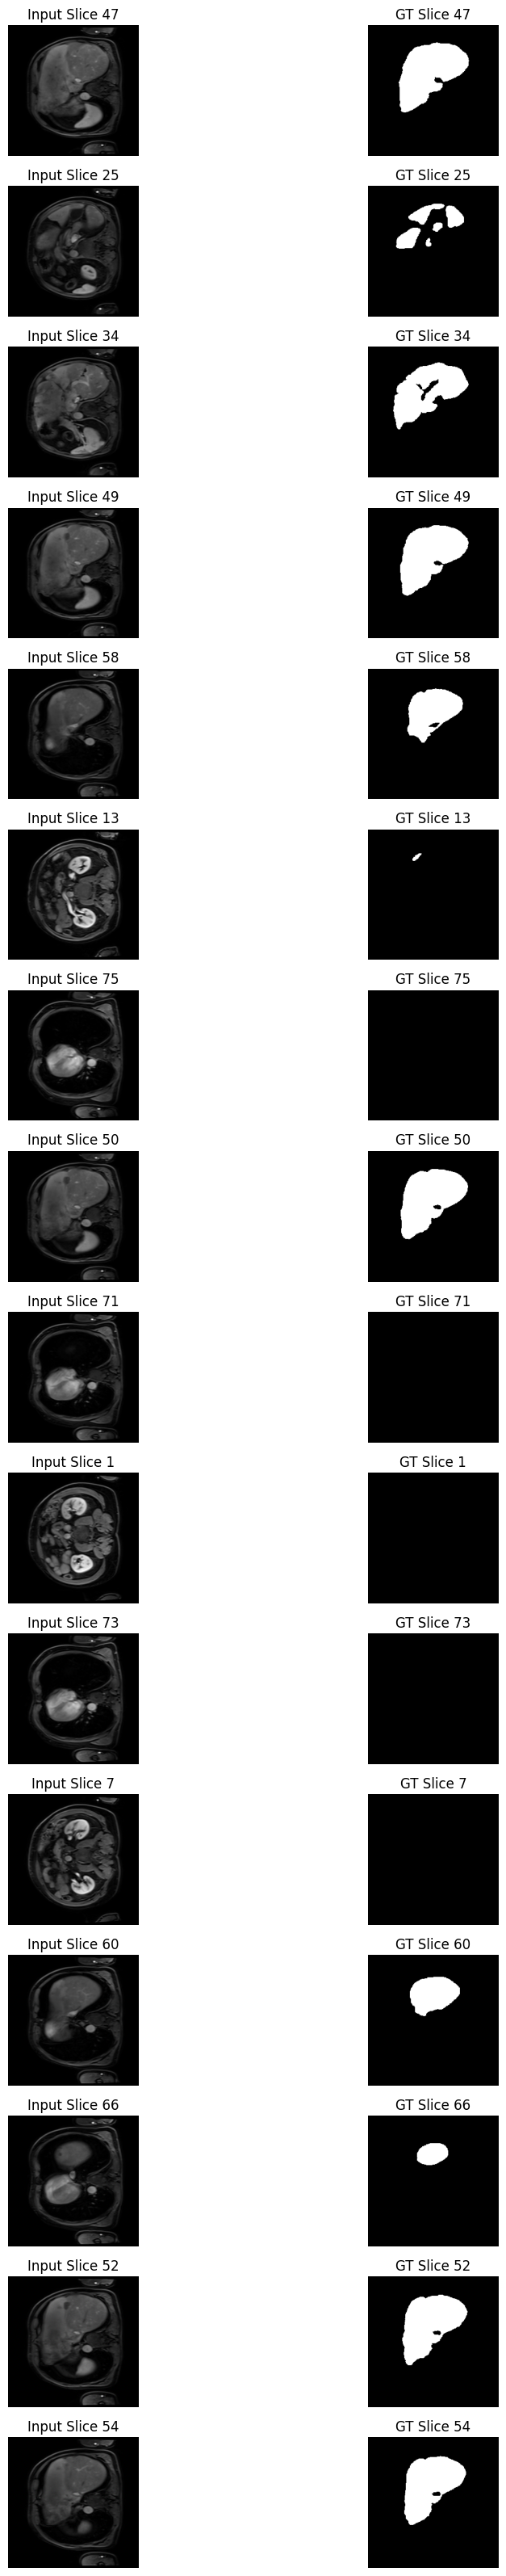

In [ ]:
# import nibabel as nib
# import numpy as np
# import matplotlib.pyplot as plt
# import random
# import os

# # Path to case_00001
# case_path = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/case_00001"
# image_path = os.path.join(case_path, "imaging.nii.gz")
# label_path = os.path.join(case_path, "segmentation.nii.gz")

# # Load volumes
# image = nib.load(image_path).get_fdata()  # shape: (D, H, W)
# label = nib.load(label_path).get_fdata()  # shape: (D, H, W)

# print("Image Shape :", image.shape)
# print("Label Shape :", label.shape)
# print("Unique labels:", np.unique(label))

# # Normalize image for better visualization
# image = (image - image.min()) / (image.max() - image.min())

# # Get valid slice indices
# num_slices = image.shape[0]
# slice_indices = random.sample(range(num_slices), 16)

# # Plotting
# plt.figure(figsize=(12, 32))
# for idx, slice_idx in enumerate(slice_indices):
#     plt.subplot(16, 2, 2*idx + 1)
#     plt.imshow(image[slice_idx], cmap='gray')
#     plt.title(f"Input Slice {slice_idx}")
#     plt.axis('off')

#     plt.subplot(16, 2, 2*idx + 2)
#     plt.imshow(label[slice_idx], cmap='gray')
#     plt.title(f"GT Slice {slice_idx}")
#     plt.axis('off')

# plt.tight_layout()
# plt.show()


In [ ]:
# import os
# import numpy as np
# from torch.utils.data import Dataset
# from PIL import Image

# class DukeLiverDataset(Dataset):
#     def __init__(self, base_dir, list_num='', num=None, transform=None):
#         self._base_dir = base_dir
#         self.transform = transform

#         # Load the volume list from train{list_num}.list file
#         with open(os.path.join(self._base_dir, f'../train{list_num}.list'), 'r') as f:
#             self.volume_list = [line.strip() for line in f.readlines()]

#         if num is not None:
#             self.volume_list = self.volume_list[:num]

#         print(f"Total {len(self.volume_list)} volumes found.")

#     def __len__(self):
#         return len(self.volume_list)

#     def __getitem__(self, idx):
#         volume_name = self.volume_list[idx]  # e.g., "0001/11"
#         volume_path = os.path.join(self._base_dir, volume_name)

#         image_dir = os.path.join(volume_path, 'images')
#         mask_dir = os.path.join(volume_path, 'masks')

#         # Sort slice files to maintain consistent ordering
#         slice_filenames = sorted(os.listdir(image_dir))

#         images = []
#         labels = []

#         for filename in slice_filenames:
#             img_path = os.path.join(image_dir, filename)
#             mask_path = os.path.join(mask_dir, filename)

#             # Load images without converting — assuming grayscale PNGs
#             img = Image.open(img_path)
#             mask = Image.open(mask_path)

#             img_array = np.array(img, dtype=np.float32)
#             mask_array = np.array(mask, dtype=np.uint8)

#             images.append(img_array)
#             labels.append(mask_array)

#         # Stack into [D, H, W] volumes
#         image_volume = np.stack(images, axis=0)
#         label_volume = np.stack(labels, axis=0)

#         # Normalize the image volume
#         image_volume = (image_volume - np.mean(image_volume)) / np.std(image_volume)

#         sample = {
#             'image': image_volume.astype(np.float32),
#             'label': label_volume.astype(np.uint8)
#         }

#         if self.transform:
#             sample = self.transform(sample)

#         return sample


(256, 256, 16) (256, 256, 16)


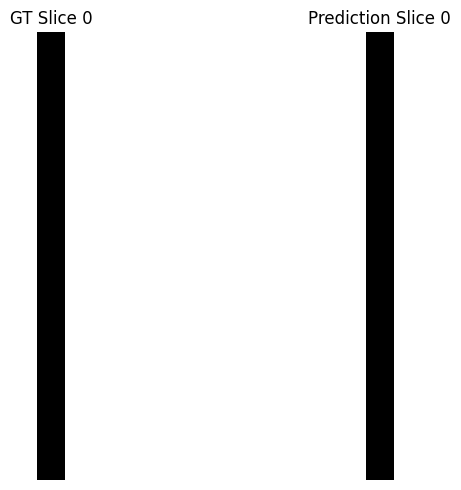

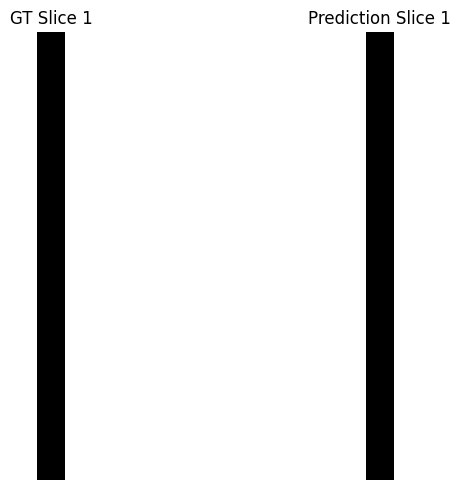

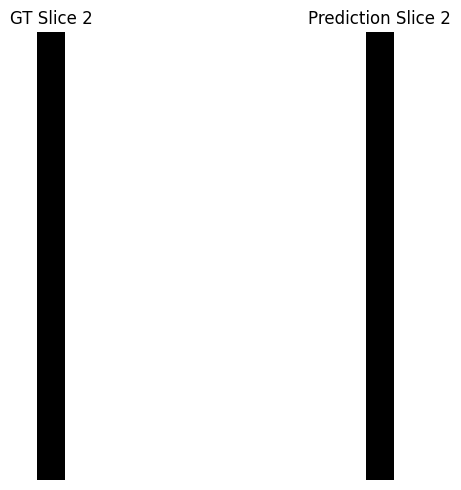

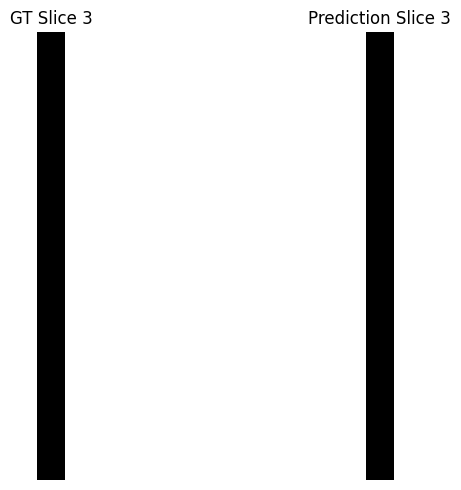

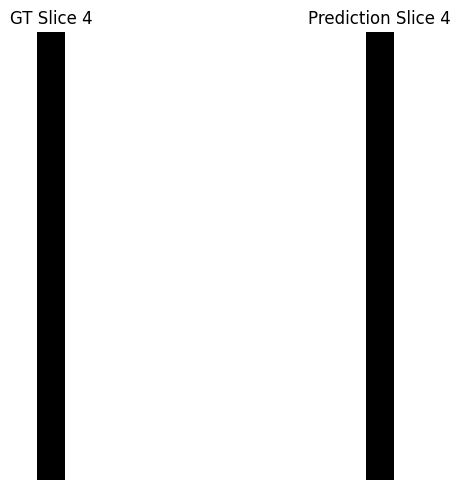

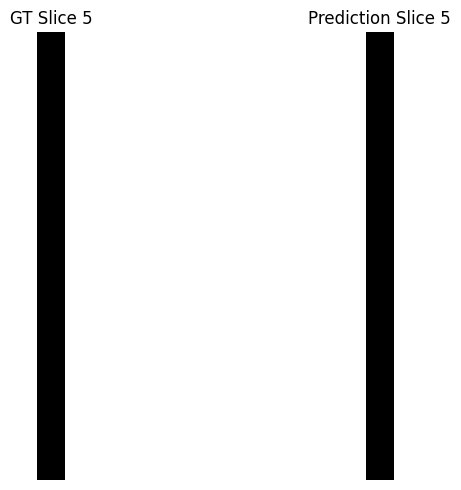

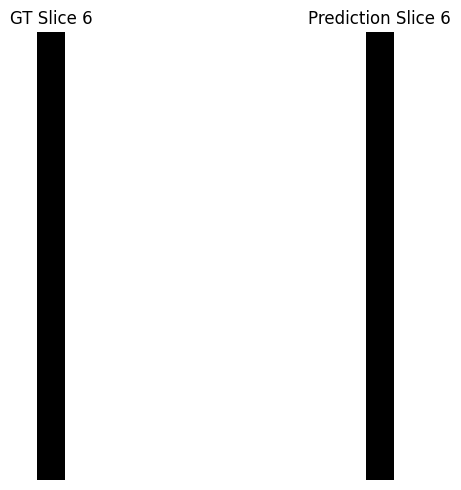

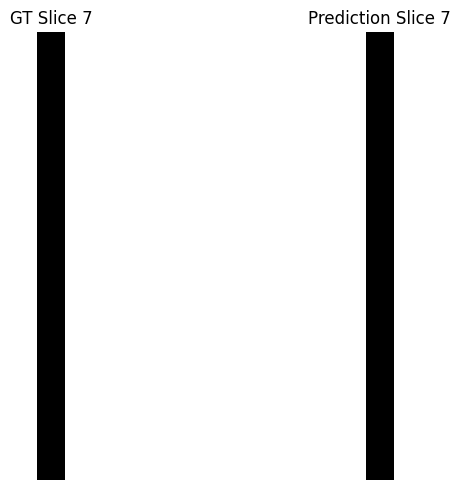

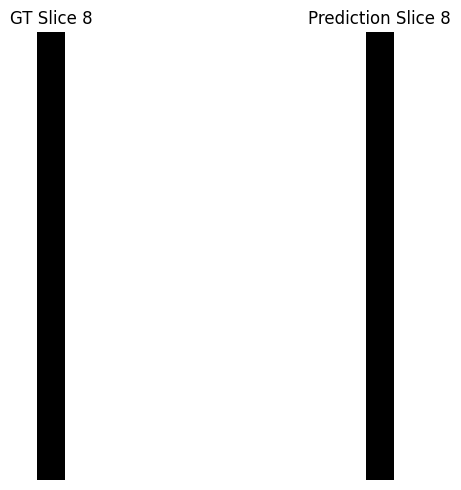

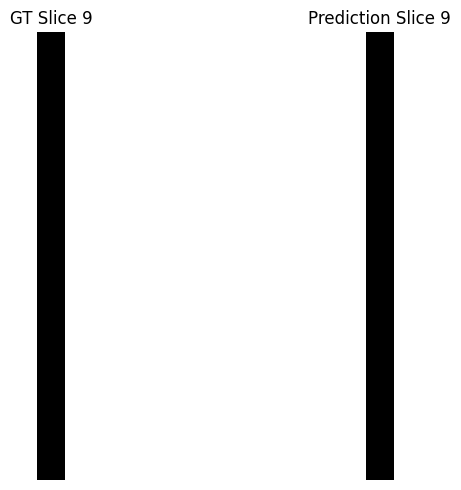

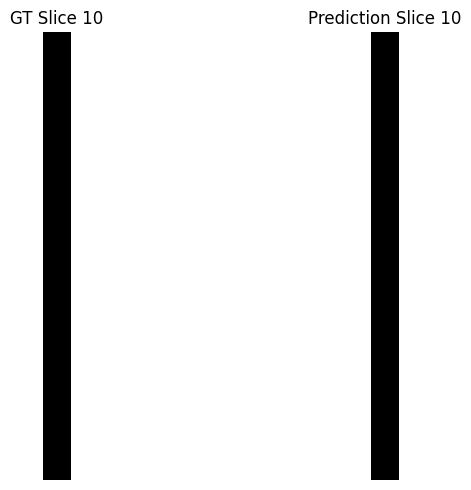

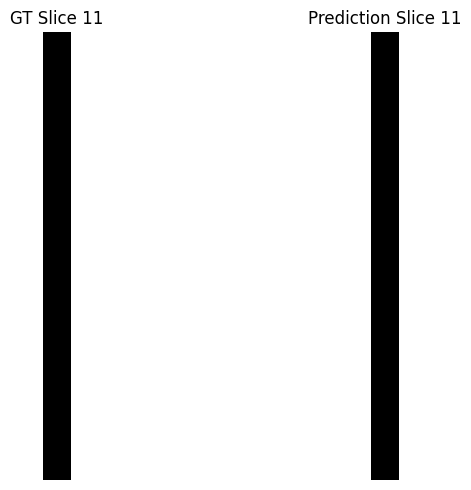

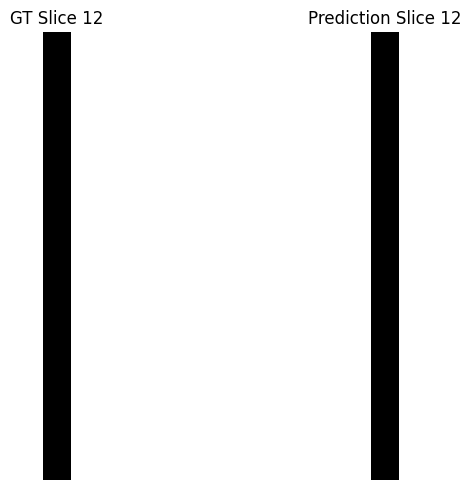

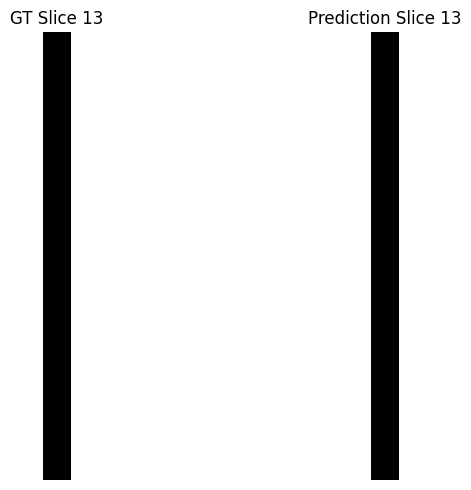

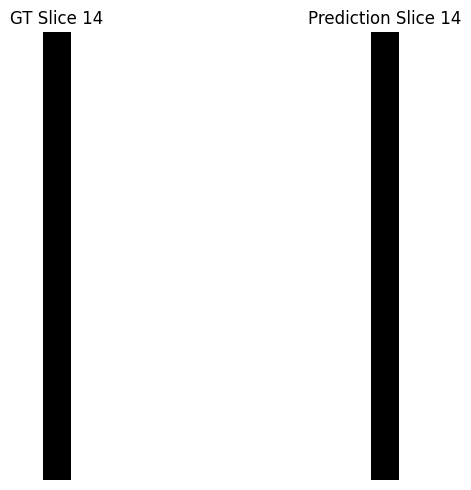

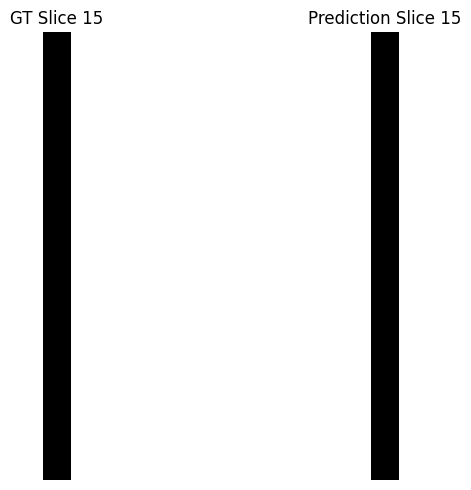

In [7]:
import nibabel as nib
import matplotlib.pyplot as plt
import time

# Load ground truth and prediction
gt = nib.load('/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/3d_kits19_WA/saveimg/gt_11750.nii.gz').get_fdata()
pred = nib.load('/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/3d_kits19_WA/saveimg/pred_seg_11750_u.nii.gz').get_fdata()

# gt_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/eps_ft/savevalimg/inshape_gt_11970.nii.gz'
# pred_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/eps_ft/savevalimg/inshape_pred_11970_u.nii.gz'
# gt =  nib.load(gt_path).get_fdata()
# pred = nib.load(pred_path).get_fdata()                                                                                                                               


# Ensure shape match
assert gt.shape == pred.shape, "Shape mismatch between GT and prediction!"
print(gt.shape, pred.shape)
for i in range(gt.shape[2]):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    axs[0].imshow(gt[i], cmap='gray')
    axs[0].set_title(f"GT Slice {i}")
    axs[0].axis('off')
    
    axs[1].imshow(pred[i], cmap='gray')
    axs[1].set_title(f"Prediction Slice {i}")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.pause(0.2)
    plt.close(fig)


In [ ]:
import nibabel as nib
import numpy as np

def load_nifti_volume(path):
    """
    Loads a .nii or .nii.gz file and returns the volume data as a NumPy array.
    """
    nii = nib.load(path)
    return nii.get_fdata().astype(np.uint8)  # ensure binary for segmentation masks

def dice_score(pred, gt, smooth=1e-6):
    """
    Compute Dice coefficient between two binary volumes.
    """
    intersection = np.sum(pred * gt)
    volume_sum = np.sum(pred) + np.sum(gt)
    dice = (2. * intersection + smooth) / (volume_sum + smooth)
    return dice

avg_dice_score = 0.0
total_samples = 0
for i in range(63, 11970, 63):
    # Replace these with your actual file paths
    gt_path = f'/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/eps_ft/savevalimg/gt_{i}.nii.gz'
    pred_path = f'/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/eps_ft/savevalimg/pred_eps_{i}_u.nii.gz'

    # Load volumes
    gt_volume = load_nifti_volume(gt_path)
    pred_volume = load_nifti_volume(pred_path)
    # print(gt_volume.shape)
    # print(pred_volume.shape)
    # Optional: ensure binary masks (0 and 1)
    gt_volume = (gt_volume > 0).astype(np.uint8)
    pred_volume = (pred_volume > 0).astype(np.uint8)
    
    
    # Check dimensions match
    assert gt_volume.shape == pred_volume.shape, f"Shape mismatch: {gt_volume.shape} vs {pred_volume.shape}"

    # Compute Dice Score
    dice = dice_score(pred_volume, gt_volume)
    avg_dice_score += dice
    total_samples += 1
    print(f"Dice Score: {dice:.4f}")
avg_dice_score = avg_dice_score/total_samples
print("Average Dice Score for the given number of volumes :", avg_dice_score)


(512, 512, 4) (512, 512, 4)


Exception: 

In [ ]:
import nibabel as nib
import numpy as np

def load_nifti_volume(path):
    """
    Loads a .nii or .nii.gz file and returns the volume data as a NumPy array.
    """
    nii = nib.load(path)
    return nii.get_fdata().astype(np.uint8)  # ensure binary for segmentation masks

def dice_score(pred, gt, smooth=1e-6):
    """
    Compute Dice coefficient between two binary volumes.
    """
    intersection = np.sum(pred * gt)
    volume_sum = np.sum(pred) + np.sum(gt)
    dice = (2. * intersection + smooth) / (volume_sum + smooth)
    return dice

# Replace these with your actual file paths
# gt_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/2x2results/saveimg/gt_eps_11750_u.nii.gz'
# pred_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/2x2results/saveimg/pred_eps_11750_u.nii.gz'
gt_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/3d_seg/saveimg/gt_11250.nii.gz'
# pred_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/3d_seg/saveimg/pred_sam_11250_u.nii.gz'
pred_seg_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/3d_seg/saveimg/pred_seg_11250_u.nii.gz'
# Load volumes
gt_volume = load_nifti_volume(gt_path)
# pred_volume = load_nifti_volume(pred_path)
pred_seg_volume = load_nifti_volume(pred_seg_path)
# gt_volume = gt_volume[0]
# pred_volume = pred_volume[0]
# print(gt_volume.shape)
# print(pred_volume.shape)
# print(pred_seg_volume.shape)
# raise Exception
# Optional: ensure binary masks (0 and 1

gt_volume = (gt_volume > 0).astype(np.uint8)
pred_volume = (pred_volume > 0).astype(np.uint8)

# print(np.unique(gt_volume), gt_volume.shape)
# print(np.unique(pred_volume), pred_volume.shape)
# print(np.unique(pred_seg_volume), pred_seg_volume.shape)
# Check dimensions match
assert gt_volume.shape == pred_volume.shape, f"Shape mismatch: {gt_volume.shape} vs {pred_volume.shape}"

# Compute Dice Score
dice = dice_score(pred_seg_volume, gt_volume)
print(f"Dice Score: {dice:.4f}")


Dice Score: 0.9161


(256, 256, 16) (256, 256, 16)


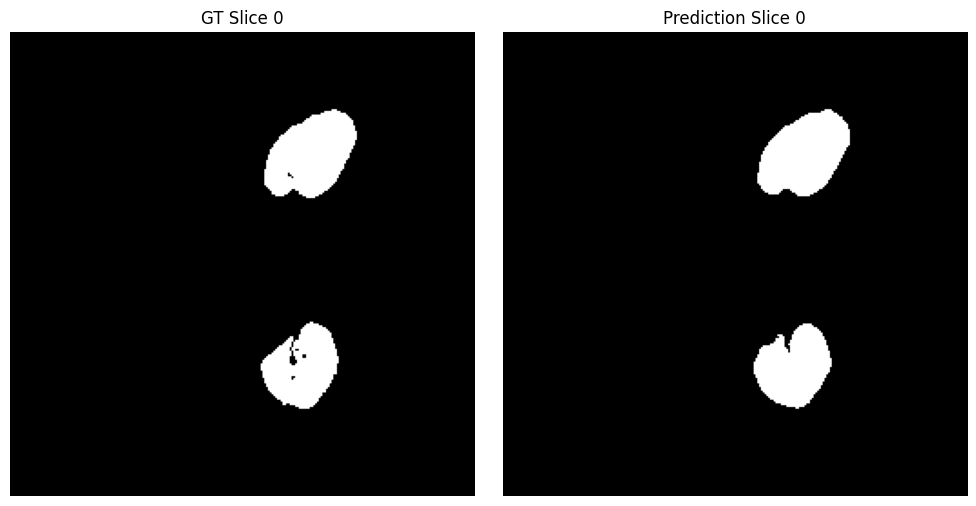

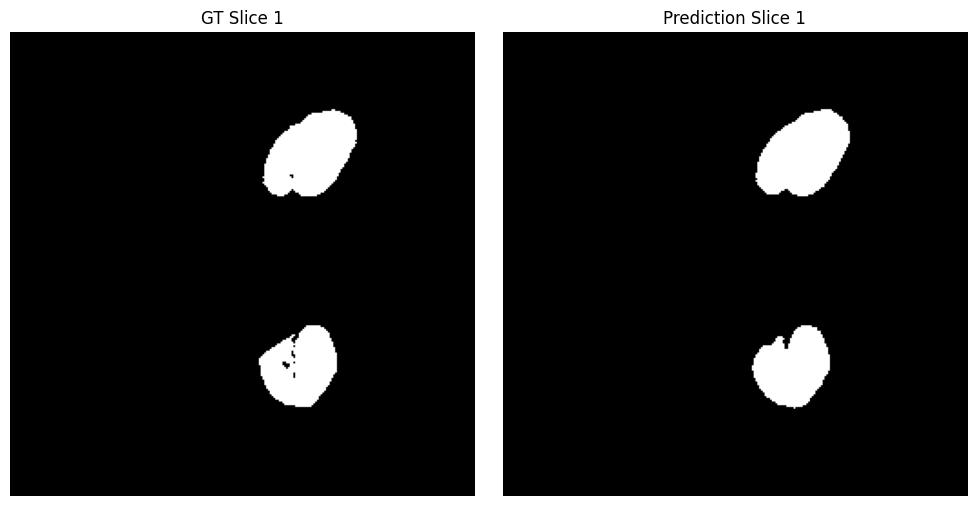

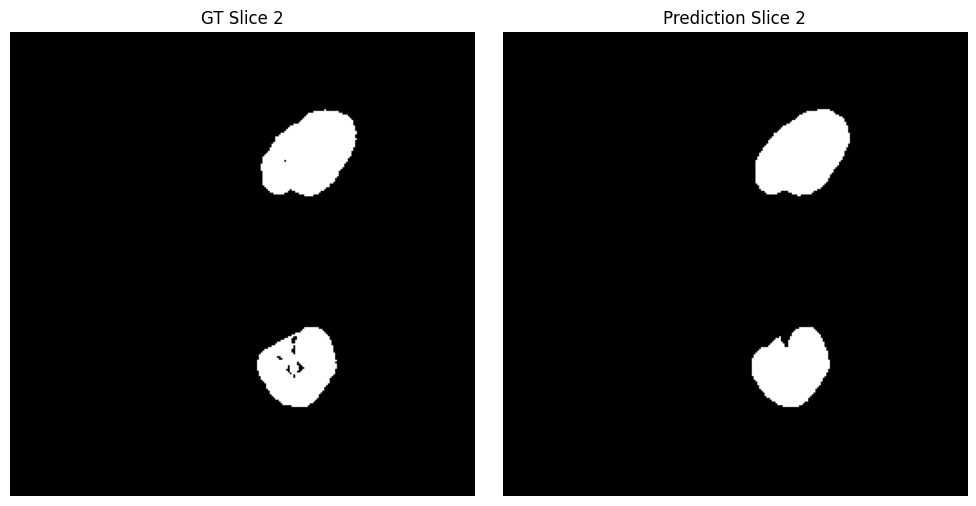

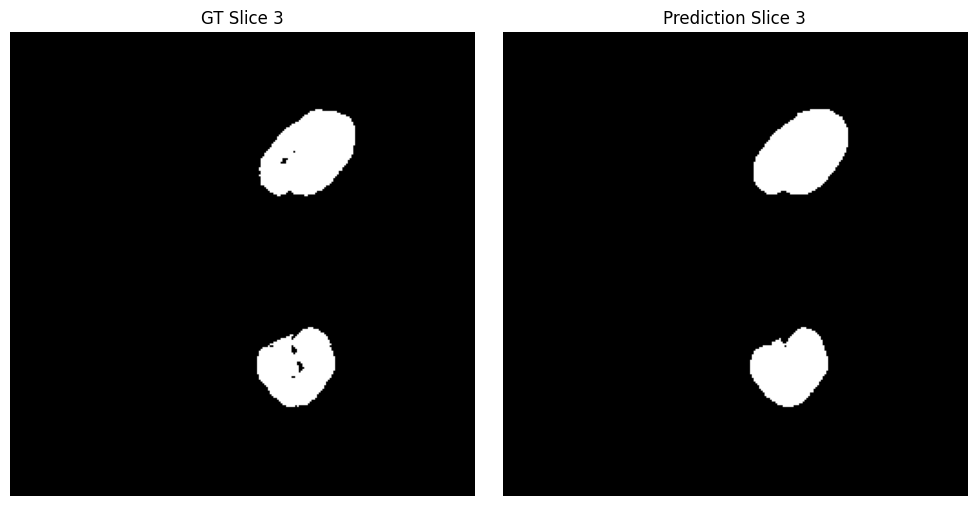

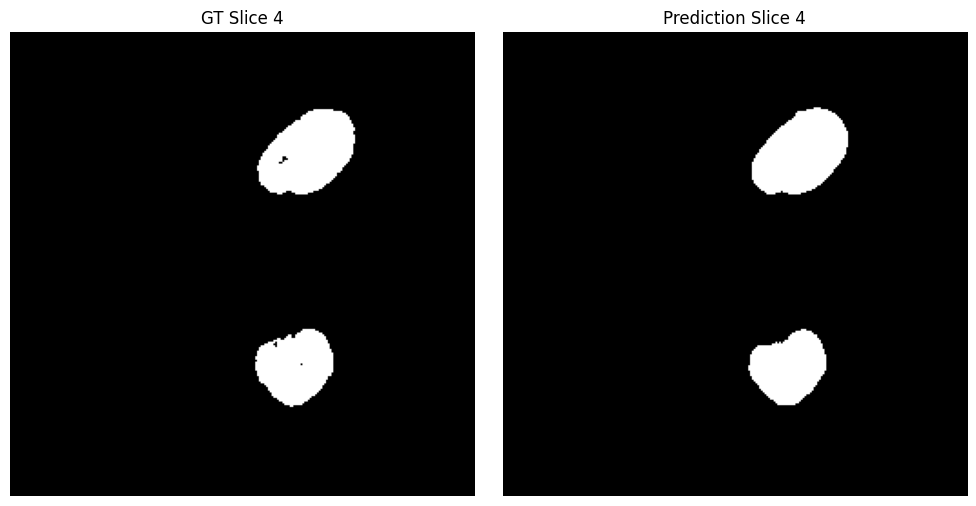

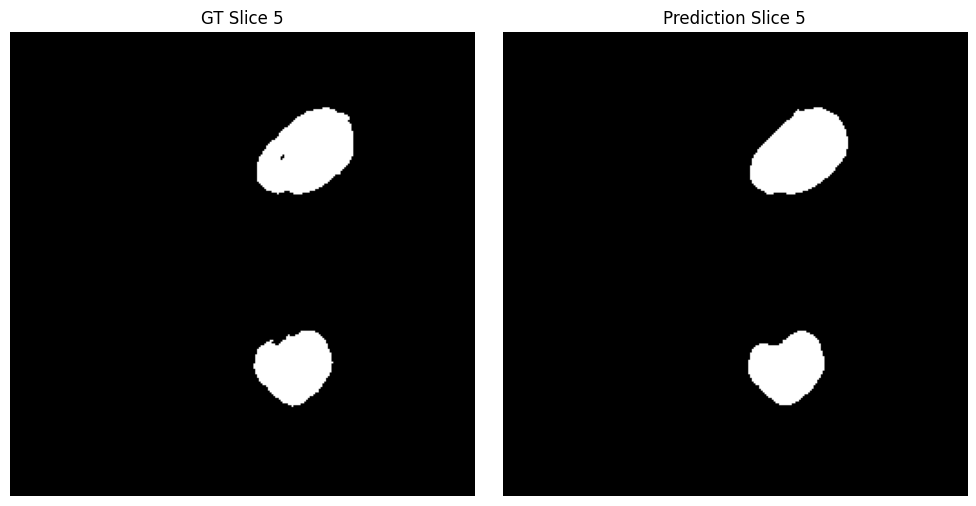

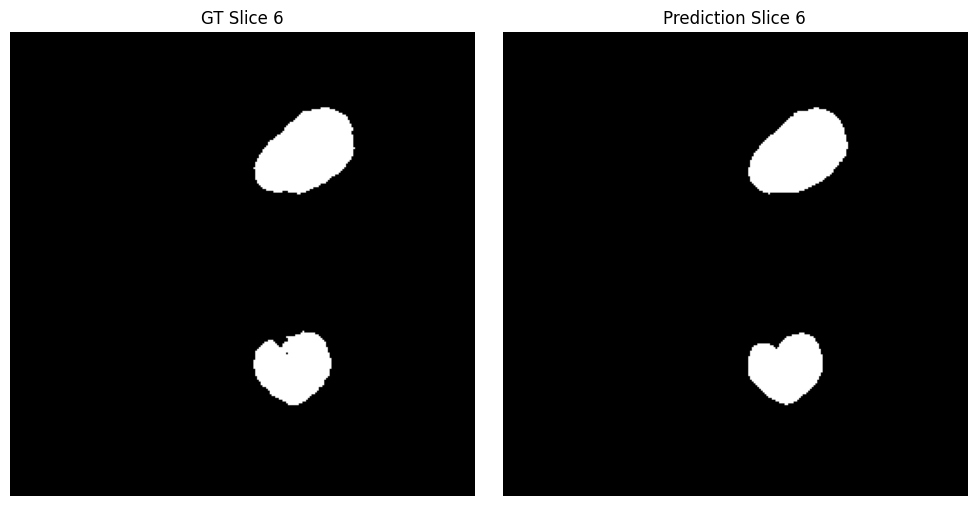

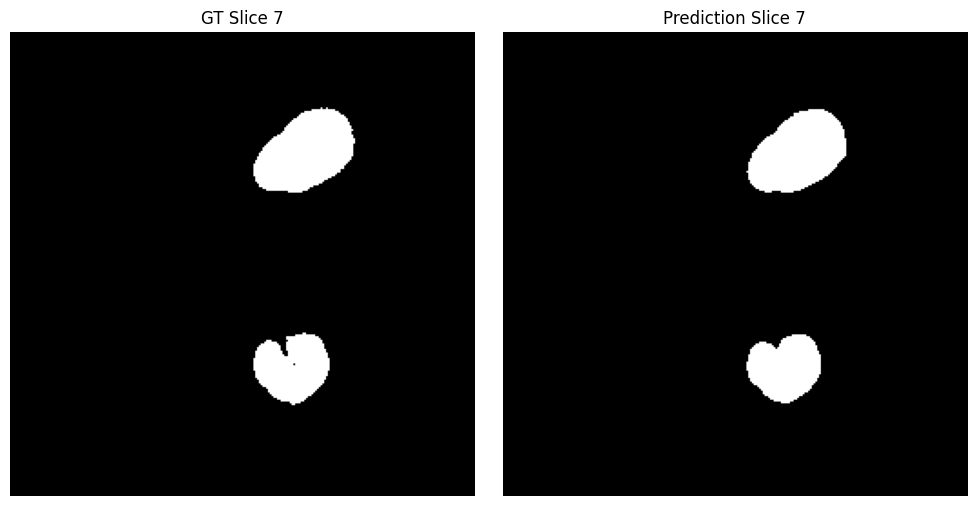

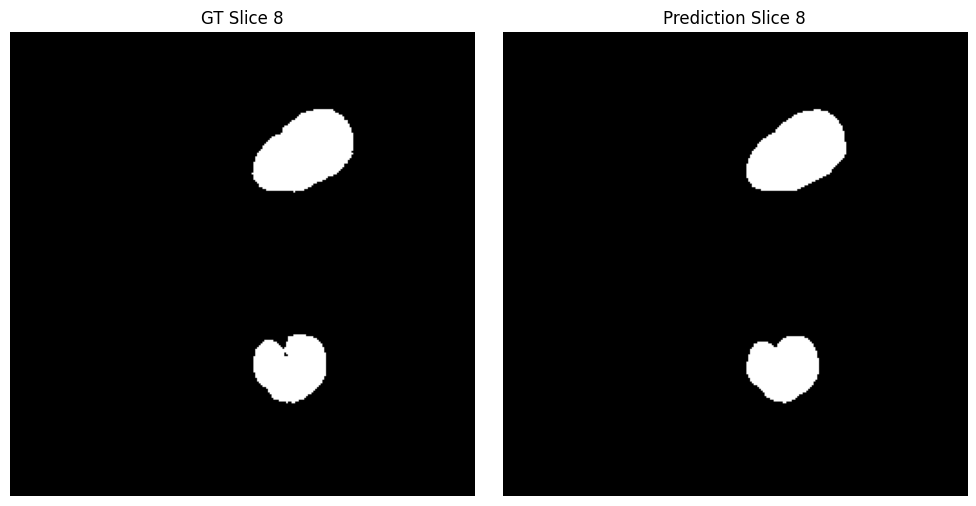

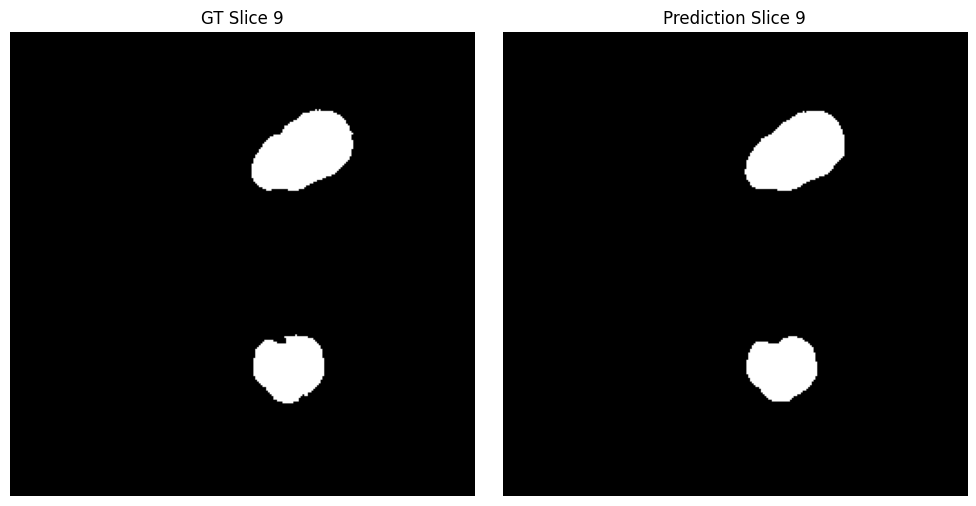

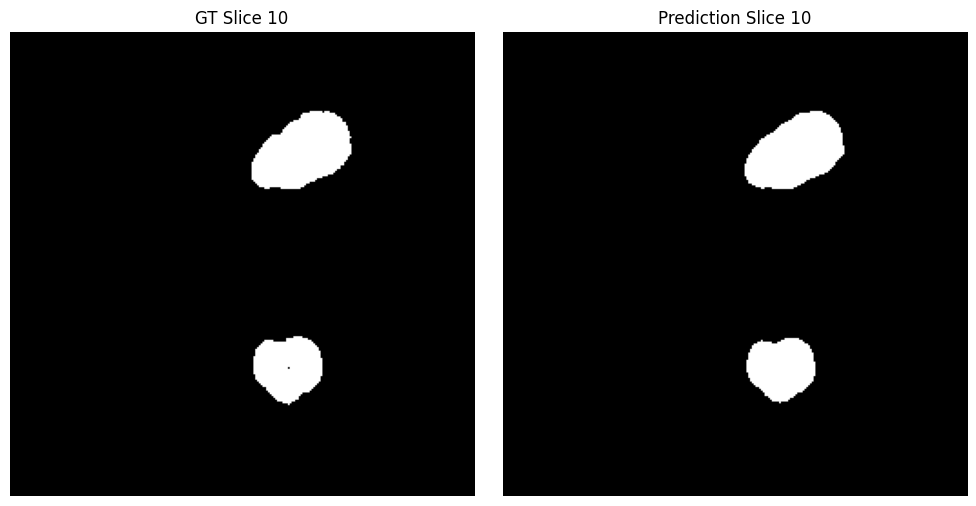

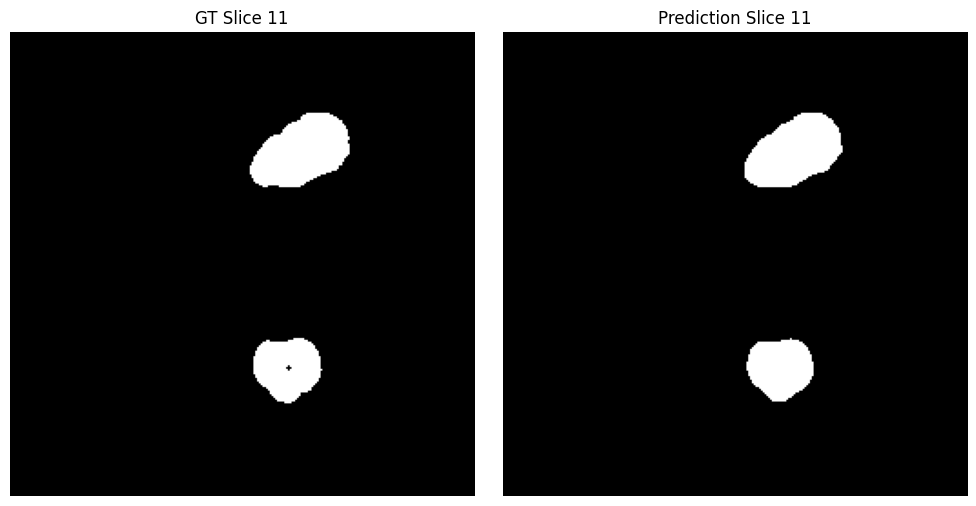

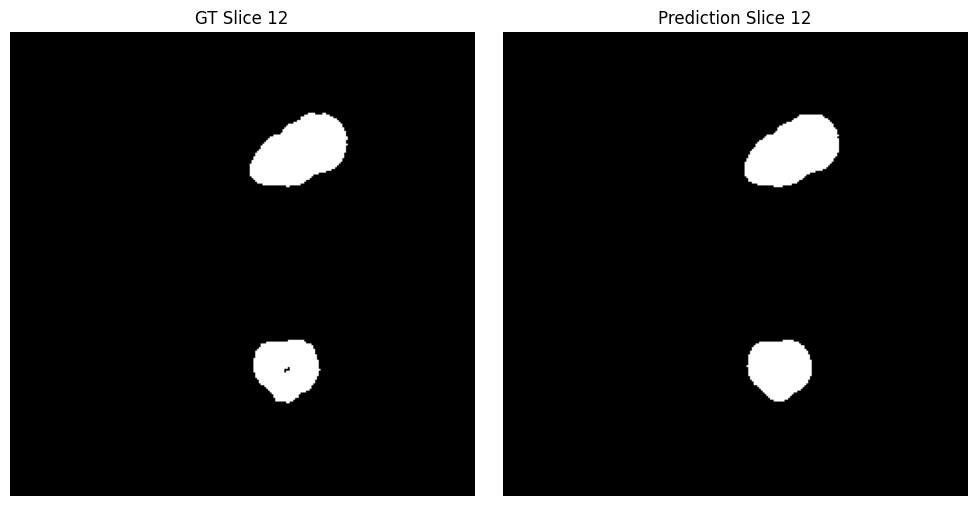

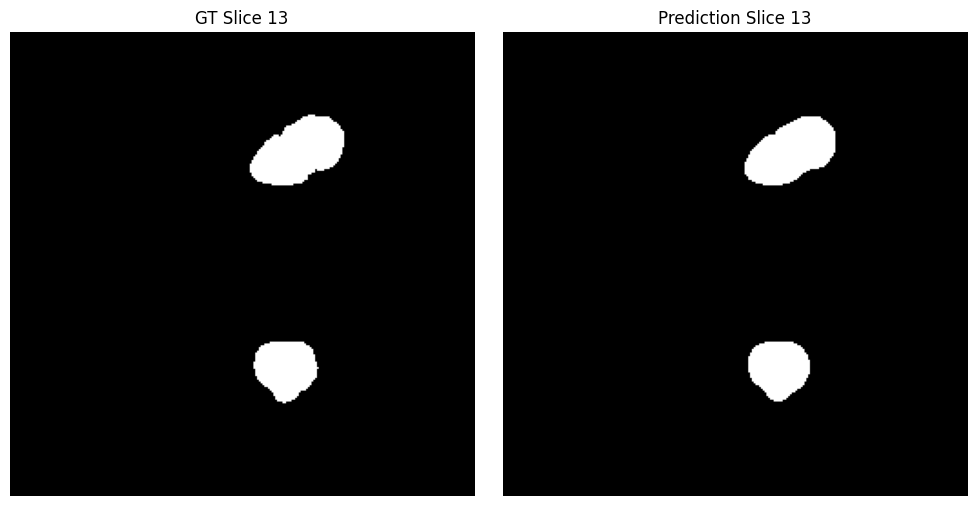

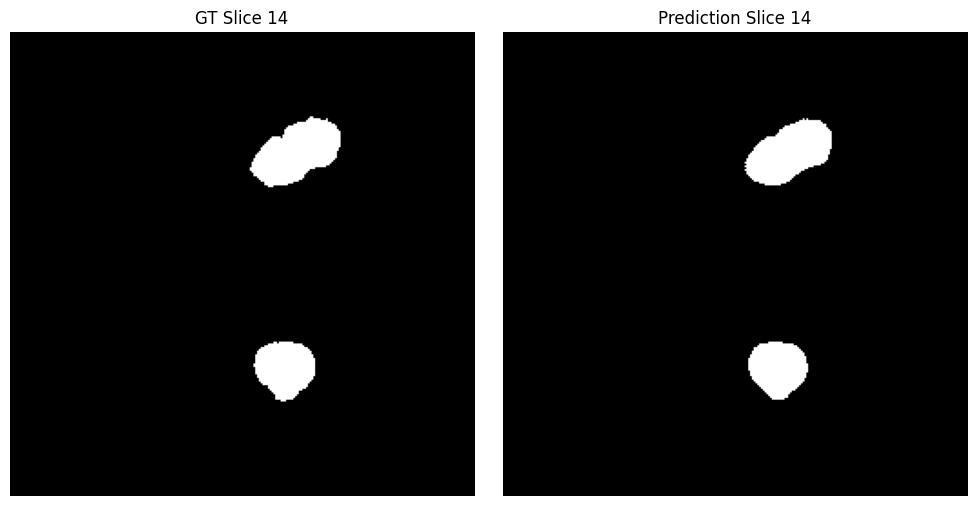

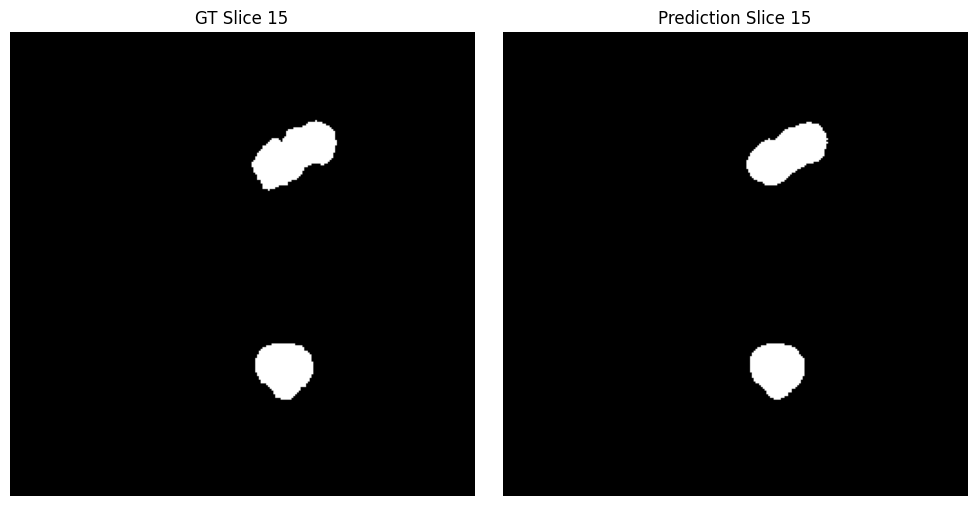

In [13]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load volumes
gt_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/3d_kits19_WA/saveimg/gt_11500.nii.gz'
pred_seg_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/3d_kits19_WA/saveimg/pred_seg_11500_u.nii.gz'

gt = nib.load(gt_path).get_fdata()
pred = nib.load(pred_seg_path).get_fdata()

# Confirm matching shapesdin
assert gt.shape == pred.shape, f"Shape mismatch: {gt.shape} vs {pred.shape}"

print(gt.shape, pred.shape)

# Loop through all 64 slices along Z (last axi
for i in range(gt.shape[2]):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(gt[:, :, i], cmap='gray')
    axs[0].set_title(f"GT Slice {i}")
    axs[0].axis('off')

    axs[1].imshow(pred[:, :, i], cmap='gray')
    axs[1].set_title(f"Prediction Slice {i}")
    axs[1].axis('off')

    plt.tight_layout()
    plt.pause(0.2)
    plt.close(fig) 



In [ ]:

import numpy as np # Import the NumPy library for numerical operations (especially array manipulation)
import random    # Import the random module for shuffling lists
import torch     # Import the PyTorch library (though not directly used in this class, it's often part of the context)

class CustomSliceSampler: # Define a new Python class named CustomSliceSampler
    def __init__(self, target_depth=16, mask_ratio=0.8, pad_value_image=0, pad_value_label=255):
        """
        Initializes the custom slice sampler.

        Args:
            target_depth (int): The desired number of slices in the output volume. (Default: 16)
            mask_ratio (float): The desired ratio of masked (non-blank) slices
                                 in the output volume (e.g., 0.8 for 80%). (Default: 0.8)
            pad_value_image (float): Value to pad image slices if not enough are available. (Default: 0)
            pad_value_label (int): Value to pad label slices if not enough are available. (Default: 255)
        """
        self.target_depth = target_depth # Store the target depth (e.g., 16) as an instance variable
        # Calculate the number of masked slices needed, rounding to the nearest integer
        self.num_mask_needed = round(target_depth * mask_ratio)
        # Calculate the number of blank slices needed, ensuring the total sums to target_depth
        self.num_blank_needed = target_depth - self.num_mask_needed
        self.pad_value_image = pad_value_image # Store the image padding value
        self.pad_value_label = pad_value_label # Store the label padding value

    def __call__(self, sample): # Define the __call__ method, making instances of this class callable like a function
                                # This method is automatically invoked when the transform is applied in transforms.Compose
        image, label = sample['image'], sample['label'] # Extract 'image' and 'label' NumPy arrays from the input 'sample' dictionary
                                                        # Assumes 'image' and 'label' have shape (W, H, D) from Kits19 dataset

        original_depth = image.shape[2] # Get the current depth (number of slices) of the input volume (e.g., 86)
        height, width = image.shape[0], image.shape[1] # Get the height and width of the slices

        # 1. Identify blank and non-blank slices
        mask_indices = []  # Initialize an empty list to store indices of slices with masks
        blank_indices = [] # Initialize an empty list to store indices of blank slices

        for d in range(original_depth): # Loop through each slice in the original volume along the depth dimension
            # Check if the current label slice (label[:, :, d]) contains any foreground pixels (value > 0)
            # np.any() returns True if any element in the array satisfies the condition
            if np.any(label[:, :, d] > 0):
                mask_indices.append(d) # If it has a mask, add its depth index to mask_indices
            else:
                blank_indices.append(d) # If it's blank, add its depth index to blank_indices
        
        random.shuffle(mask_indices) # Randomly shuffle the list of masked slice indices
        random.shuffle(blank_indices) # Randomly shuffle the list of blank slice indices

        selected_slice_indices = [] # Initialize an empty list to store the indices of the 16 chosen slices

        # 2. Select masked slices
        # Determine how many masked slices to select: the minimum of what's needed and what's available
        num_selected_mask = min(self.num_mask_needed, len(mask_indices))
        # Add these selected masked slice indices to the main list of selected indices
        selected_slice_indices.extend(mask_indices[:num_selected_mask])

        # 3. Select blank slices
        # Determine how many blank slices to select: the minimum of what's needed and what's available
        num_selected_blank = min(self.num_blank_needed, len(blank_indices))
        # Add these selected blank slice indices to the main list of selected indices
        selected_slice_indices.extend(blank_indices[:num_selected_blank])

        # 4. Handle cases where total selected slices are less than target_depth
        # Calculate how many more slices are still needed to reach target_depth (16)
        remaining_slots = self.target_depth - len(selected_slice_indices)

        if remaining_slots > 0: # If there are still empty slots to fill
            # First, try to fill from remaining masked slices (if we didn't pick all of them initially)
            if len(mask_indices) > num_selected_mask: # Check if there are unselected masked slices
                remaining_mask_indices = mask_indices[num_selected_mask:] # Get the remaining masked slice indices
                # Determine how many to add from these remaining masked slices
                num_to_add_from_mask = min(remaining_slots, len(remaining_mask_indices))
                # Randomly sample and add them to selected_slice_indices
                selected_slice_indices.extend(random.sample(remaining_mask_indices, num_to_add_from_mask))
                remaining_slots -= num_to_add_from_mask # Update the number of remaining slots
            
            # Then, try to fill from remaining blank slices (if we still have slots and blank slices left)
            if remaining_slots > 0 and len(blank_indices) > num_selected_blank:
                remaining_blank_indices = blank_indices[num_selected_blank:] # Get the remaining blank slice indices
                # Determine how many to add from these remaining blank slices
                num_to_add_from_blank = min(remaining_slots, len(remaining_blank_indices))
                # Randomly sample and add them to selected_slice_indices
                selected_slice_indices.extend(random.sample(remaining_blank_indices, num_to_add_from_blank))
                remaining_slots -= num_to_add_from_blank # Update the number of remaining slots
            
            # 5. Pad if still not enough slices to reach target_depth (occurs if the original volume is very small)
            if remaining_slots > 0:
                print(f"Warning: Not enough slices in volume (original depth {original_depth}) to meet target_depth ({self.target_depth}). Padding {remaining_slots} slices.")
                for _ in range(remaining_slots):
                    selected_slice_indices.append(-1) # Add a sentinel value (-1) to indicate a slice that needs padding later

        # Ensure we have exactly target_depth indices (a safety check for edge cases)
        # This trims extra slices if, by some chance, more than target_depth were selected
        if len(selected_slice_indices) > self.target_depth:
            selected_slice_indices = random.sample(selected_slice_indices, self.target_depth)
        # This pads with more sentinel values if, despite the logic above, it's still short
        elif len(selected_slice_indices) < self.target_depth:
            selected_slice_indices.extend([-1] * (self.target_depth - len(selected_slice_indices)))

        selected_slice_indices.sort() # Sort the selected indices to maintain the original relative order of slices
                                     # This is important for anatomical consistency when stitching later

        # 6. Create the new cropped image and label volumes
        cropped_image_slices = [] # List to hold the 2D image slices that will form the new 3D volume
        cropped_label_slices = [] # List to hold the 2D label slices

        for idx in selected_slice_indices: # Iterate through the chosen slice indices
            if idx != -1: # If the index is not the sentinel padding value
                cropped_image_slices.append(image[:, :, idx]) # Append the actual image slice
                cropped_label_slices.append(label[:, :, idx]) # Append the actual label slice
            else: # If the index is -1 (meaning it's a padded slice)
                # Create a blank image slice filled with pad_value_image (e.g., 0)
                cropped_image_slices.append(np.full((height, width), self.pad_value_image, dtype=image.dtype))
                # Create a blank label slice filled with pad_value_label (e.g., 255)
                cropped_label_slices.append(np.full((height, width), self.pad_value_label, dtype=label.dtype))
        
        # Stack the collected 2D slices along a new axis (axis=2) to form the 3D volume
        cropped_image = np.stack(cropped_image_slices, axis=2) # Resulting shape (W, H, target_depth)
        cropped_label = np.stack(cropped_label_slices, axis=2) # Resulting shape (W, H, target_depth)

        # Update the 'sample' dictionary with the newly created cropped volumes
        sample['image'] = cropped_image
        sample['label'] = cropped_label.astype(np.uint8) # Ensure the label data type is unsigned 8-bit integer

        return sample # Return the modified sample dictionary

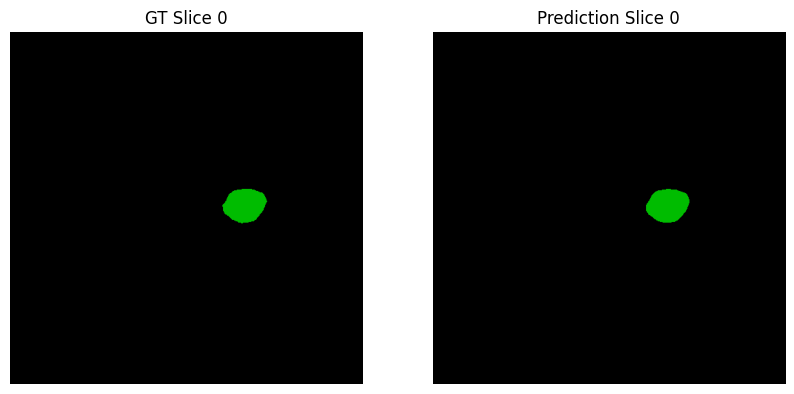

In [12]:
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Load volumes
gt = nib.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/eps_ft/savevalimg/gt_11970.nii.gz").get_fdata()
pred = nib.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/eps_ft/savevalimg/pred_eps_11970_u.nii.gz").get_fdata()

# gt = nib.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/model_duke(16 slices  results)/eps_ft/savevalimg/gt_11875.nii.gz").get_fdata()
# pred = nib.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/model_duke(16 slices  results)/eps_ft/savevalimg/pred_eps_11875_u.nii.gz").get_fdata()

# Handle orientation
if gt.shape[2] == 4:
    gt = np.transpose(gt, (2, 0, 1))     # (64, 128, 128)
    pred = np.transpose(pred, (2, 0, 1))

# Replace 255 (ignore index) in GT with 2 for visualization
gt_vis = np.copy(gt)

gt_vis[gt_vis == 255] = 2  # Use 2 as a dummy class

# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
img_gt = axs[0].imshow(gt_vis[0], cmap='nipy_spectral', vmin=0, vmax=2)
img_pred = axs[1].imshow(pred[0], cmap='nipy_spectral', vmin=0, vmax=2)
axs[0].set_title("GT")
axs[1].set_title("Prediction")
for ax in axs: ax.axis('off')

# Animation update function
def update(i):
    img_gt.set_data(gt_vis[i])
    img_pred.set_data(pred[i])
    axs[0].set_title(f"GT Slice {i}")
    axs[1].set_title(f"Prediction Slice {i}")
    return img_gt, img_pred

ani = animation.FuncAnimation(fig, update, frames=gt.shape[0], interval=1000)

# Save to video
ani.save("gt_vs_pred_animation_.mp4", writer='ffmpeg', dpi=200)

# Optional: Display live if not headless
# plt.show()


In [30]:
from detectron2.config import get_cfg, CfgNode
from detectron2.utils.events import _CURRENT_STORAGE_STACK, EventStorage

def add_custom_param(cfg):
    """
    In order to add custom config parameter in the .yaml those parameter must
    be initialised
    """
    # Model
    cfg.MODEL_CUSTOM = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE.EFFICIENTNET_ID = 7
    cfg.MODEL_CUSTOM.BACKBONE.LOAD_PRETRAIN = True
    # DATASET
    cfg.NUM_CLASS = 2
    cfg.DATASET_PATH = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset"
    cfg.TRAIN_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset/output/cityscapes_panoptic_train.json"
    cfg.VALID_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset/output/cityscapes_panoptic_val.json"
    cfg.PRED_DIR = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset/preds"
    cfg.PRED_JSON = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset/preds/cityscapes_panoptic_preds.json"
    # Transfom
    cfg.TRANSFORM = CfgNode()
    cfg.TRANSFORM.NORMALIZE = CfgNode()
    cfg.TRANSFORM.NORMALIZE.MEAN = (106.433, 116.617, 119.559)
    cfg.TRANSFORM.NORMALIZE.STD = (65.496, 67.6, 74.123)
    cfg.TRANSFORM.RESIZE = CfgNode()
    cfg.TRANSFORM.RESIZE.HEIGHT = 1024
    cfg.TRANSFORM.RESIZE.WIDTH = 1024
    cfg.TRANSFORM.RANDOMCROP = CfgNode()
    cfg.TRANSFORM.RANDOMCROP.HEIGHT = 1024
    cfg.TRANSFORM.RANDOMCROP.WIDTH = 1024
    cfg.TRANSFORM.HFLIP = CfgNode()
    cfg.TRANSFORM.HFLIP.PROB = 0.5
    # Solver
    cfg.SOLVER.NAME = "Adam"
    cfg.SOLVER.ACCUMULATE_GRAD = 1
    cfg.SOLVER.MAX_EPOCHS = 40
    # Runner
    cfg.BATCH_SIZE = 2
    cfg.CHECKPOINT_PATH = ""
    cfg.PRECISION = 32
    # Callbacks
    cfg.CALLBACKS = CfgNode()
    cfg.CALLBACKS.CHECKPOINT_DIR = None
    # Inference
    cfg.INFERENCE = CfgNode()
    cfg.INFERENCE.AREA_TRESH = 64


cfg = get_cfg()
add_custom_param(cfg)
cfg.merge_from_file("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/code/config.yaml")

Config '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/code/config.yaml' has no VERSION. Assuming it to be compatible with latest v2.


In [33]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from SFR.code.dataloaders.dataset import RandomCrop, ToTensor
# Define your preprocessing (same as training)
transform = transforms.Compose([
    # RandomRotFlip(),  # Not used in inference
    RandomCrop((256, 256, 16)),  # Optional for inference
    ToTensor(),  # Ensure it converts to torch.Tensor and adds channel
])

def load_volume_with_transform(volume_path, transform=None):
    image_dir = os.path.join(volume_path, 'images')
    mask_dir = os.path.join(volume_path, 'masks')

    slice_filenames = sorted(os.listdir(image_dir))

    images, labels = [], []
    for filename in slice_filenames:
        img_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)

        img = Image.open(img_path)
        mask = Image.open(mask_path)

        img_array = np.array(img, dtype=np.float32)
        mask_array = np.array(mask, dtype=np.uint8)

        images.append(img_array)
        labels.append(mask_array)

    image_volume = np.stack(images, axis=0)  # [D, H, W]
    label_volume = np.stack(labels, axis=0)

    # Transpose to [H, W, D]
    image_volume = np.transpose(image_volume, (1, 2, 0))
    label_volume = np.transpose(label_volume, (1, 2, 0))

    # Normalize image
    image_volume = (image_volume - np.mean(image_volume)) / np.std(image_volume)

    sample = {
        'image': image_volume,
        'label': label_volume
    }

    if transform:
        sample = transform(sample)

    return sample

# ---- Volume paths ---- #
volume_paths = [
    "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/Converted_Liver_DaTA/0025/19",
    "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/Converted_Liver_DaTA/0007/8"
]

# ---- Load and transform volumes ---- #
samples = [load_volume_with_transform(path, transform=transform) for path in volume_paths]

# ---- Stack into batch ---- #
batch = {
    'image': torch.stack([s['image'] for s in samples]),  # [B, 1, H, W, D]
    'label': torch.stack([s['label'] for s in samples])   # [B, 1, H, W, D]
}

# ---- Print shape to confirm ---- #
print("Batch image shape:", batch['image'].shape)
print("Batch label shape:", batch['label'].shape)

Batch image shape: torch.Size([2, 1, 256, 256, 16])
Batch label shape: torch.Size([2, 256, 256, 16])


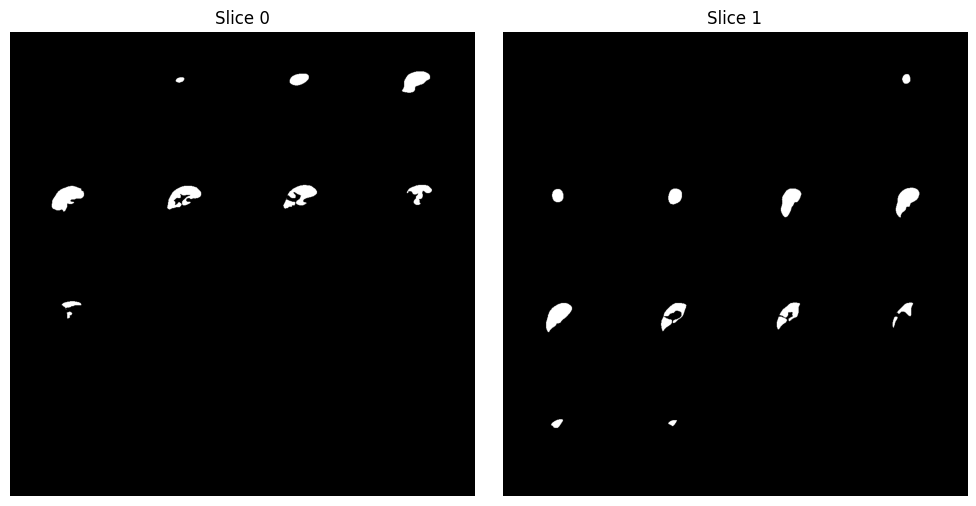

In [34]:
from SFR.code.utils.util import *

image = batch['image'].cpu().detach().numpy()
label = batch['label'].cpu().detach().numpy()
image_inshape, label_inshape, n_row, n_col, pw, ph, ps, pww, phh, s_l, s_w = Spread_bs_aug(image, label, 1024, 2, 0.5)  # (B, 1024, 1024)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(label_inshape[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f"Slice {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from SFR.code.efficientps.model import EffificientPS
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EffificientPS(cfg) 
model.to(device) # Initialize with the same config
checkpoint = torch.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_kits19/eps_ft/eps_iter_best_11592.pth")
model.load_state_dict(checkpoint)

Loaded pretrained weights for efficientnet-b7


/tmp/ipykernel_2204329/3708253518.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/mod

<All keys matched successfully>

In [36]:
if True:     # 2d RandomRotFlip
    k = np.array([np.random.randint(0, 4) for _ in range(image_inshape.shape[0])])
    axis = np.array([np.random.randint(0, 2) for _ in range(image_inshape.shape[0])])
    for i in range(image_inshape.shape[0]):
        image_inshape[i] = RandomRotFlip_2d(image_inshape[i], k[i], axis[i])
        label_inshape[i] = RandomRotFlip_2d(label_inshape[i], k[i], axis[i])

volume_batch_inshape, label_batch_inshape = ToTensor_sam_bs(image_inshape, label_inshape)  # [B, 3, 1024, 1024], [B, 1024, 1024]
    
volume_batch_inshape = volume_batch_inshape.to(device)
label_batch_inshape = label_batch_inshape.to(device)
batch = dict()
batch['image'] = volume_batch_inshape
semantic = label_batch_inshape

batch['semantic'] = torch.where(semantic == 0, torch.tensor(0, dtype=semantic.dtype, device=semantic.device),
            torch.where(semantic == 255, torch.tensor(1, dtype=semantic.dtype, device=semantic.device), semantic))

outputs, loss = model.shared_step(batch)
output_masks = outputs['semantic']

output_soft = F.softmax(output_masks, dim=1)                    # [1, 2, 1024, 1024]
label_batch_inshape = torch.where(label_batch_inshape == 255,
                        torch.tensor(1, dtype=label_batch_inshape.dtype, device=label_batch_inshape.device),
                        label_batch_inshape)


RuntimeError: NVML_SUCCESS == DriverAPI::get()->nvmlInit_v2_() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":963, please report a bug to PyTorch. 

[0 1]


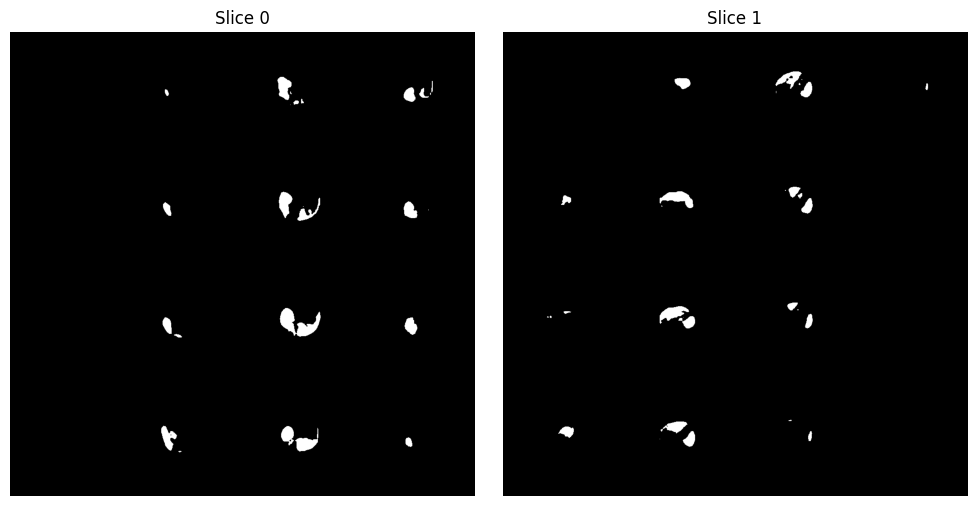

In [ ]:
prediction_inshape = torch.argmax(output_soft, dim=1)  # (B, 1024, 1024)
prediction_inshape = prediction_inshape.cpu().detach().numpy()  # (B, 1024, 1024)
print(np.unique(prediction_inshape))
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

for i in range(2): 
    plt.subplot(1, 2, i + 1)
    plt.imshow(prediction_inshape[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f"Slice {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [38]:
batch_size = 2
volume_batch, label_batch = batch['image'], batch['semantic']
eps_volume_batch = volume_batch.cpu().detach().numpy()
eps_label_batch = label_batch.cpu().detach().numpy()

In [39]:
if True:
    for i in range(image_inshape.shape[0]):
        prediction_inshape[i] = RandomFlipRot_2d(prediction_inshape[i], k[i]*(-1), axis[i]*(-1))

pred_single = np.zeros((batch_size, image.shape[-1] + ps * 2, image.shape[-2] + pw * 2, image.shape[-3] + ph * 2))  # [B, 80, 112, 112]  (1, 112, 114, 86)
if pww < 0 or phh < 0:
    pww_r, phh_r = pww, phh
    prediction_inshape = np.pad(prediction_inshape, [(0, 0), (abs(pww), abs(pww)), (abs(phh), abs(phh))], mode='constant', constant_values=255)
    pww, phh = 0, 0

# Inverse Stitching
for row in range(n_row):
    for col in range(n_col):
        if row * n_col + col < pred_single.shape[1]:
            pred_single[:, row * n_col + col] = prediction_inshape[:, pww + row * s_l:pww + (row + 1) * s_l, phh + col * s_w:phh + (col + 1) * s_w]
pred_single = pred_single[:, ps:pred_single.shape[-3] - ps, pw:pred_single.shape[-2] - pw, ph:pred_single.shape[-1] - ph]  # (B, 64, 128, 128)
pred_single = np.swapaxes(pred_single, -3, -1)  # (B, 128, 128, 64)
prediction_eps = pred_single

prediction_binary = (prediction_eps == 1).astype(np.uint8)  # or whatever label is foreground
# label_binary = (batch['semantic'].cpu().detach().numpy() == 1).astype(np.uint8)      # ground truth foreground

eps_label_batch = np.where(eps_label_batch == 0, 
        0, 
        np.where(eps_label_batch == 255, 
                1, 
                eps_label_batch))
label = np.where(label == 0, 
        0, 
        np.where(label == 255, 
                1, 
                label))
label_binary = (label == 1).astype(np.uint8)

In [40]:
def dice_score(pred, gt, smooth=1e-6):
        """
        Compute Dice coefficient between two binary volumes.
        """
        intersection = np.sum(pred * gt)
        volume_sum = np.sum(pred) + np.sum(gt)
        dice = (2. * intersection + smooth) / (volume_sum + smooth)
        return dice

In [41]:
assert prediction_binary.shape == label.shape
batch_dice = 0.0
for b in range(prediction_binary.shape[0]):
    batch_dice = dice_score(prediction_binary[b], label_binary[b])
    print(batch_dice)

0.25434543457626646
0.22640416911665684


In [8]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from detectron2.config import get_cfg, CfgNode
from efficientps.model import EffificientPS
from dataloaders.dataset import RandomCrop, ToTensor
from utils.util import Spread_bs_aug, ToTensor_sam_bs
import random

def dice_coefficient(pred, target, epsilon=1e-5):
    intersection = np.sum(pred * target)
    union = np.sum(pred) + np.sum(target)
    dice = (2. * intersection + epsilon) / (union + epsilon)
    return dice

class LiverTestDataset(Dataset):
    def __init__(self, image_list_file, transform=None):
        with open(image_list_file, 'r') as f:
            self.image_paths = [line.strip() for line in f.readlines()]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image_dir = os.path.join(image_path, 'images')
        mask_dir = os.path.join(image_path, 'masks')

        slice_filenames = sorted(os.listdir(image_dir))

        images = []
        labels = []

        for filename in slice_filenames:
            img = Image.open(os.path.join(image_dir, filename)).convert('L')
            mask = Image.open(os.path.join(mask_dir, filename)).convert('L')

            images.append(np.array(img, dtype=np.float32))
            labels.append(np.array(mask, dtype=np.uint8))

        image_volume = np.stack(images, axis=0)
        label_volume = np.stack(labels, axis=0)

        image = np.transpose(image_volume, (1, 2, 0))
        label = np.transpose(label_volume, (1, 2, 0))
        image = (image - np.mean(image)) / np.std(image)

        sample = {'image': image, 'label': label}
        if self.transform:
            sample = self.transform(sample)

        return sample

def set_seed(seed=1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)

def add_custom_param(cfg):
    cfg.MODEL_CUSTOM = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE = CfgNode()
    cfg.MODEL_CUSTOM.BACKBONE.EFFICIENTNET_ID = 7
    cfg.MODEL_CUSTOM.BACKBONE.LOAD_PRETRAIN = True
    cfg.NUM_CLASS = 2
    cfg.DATASET_PATH = "/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/EPS_Medical_rgb/Liver_dataset"
    cfg.TRAIN_JSON = os.path.join(cfg.DATASET_PATH, "output/cityscapes_panoptic_train.json")
    cfg.VALID_JSON = os.path.join(cfg.DATASET_PATH, "output/cityscapes_panoptic_val.json")
    cfg.PRED_DIR = os.path.join(cfg.DATASET_PATH, "preds")
    cfg.PRED_JSON = os.path.join(cfg.DATASET_PATH, "preds/cityscapes_panoptic_preds.json")
    cfg.TRANSFORM = CfgNode()
    cfg.TRANSFORM.NORMALIZE = CfgNode()
    cfg.TRANSFORM.NORMALIZE.MEAN = (106.433, 116.617, 119.559)
    cfg.TRANSFORM.NORMALIZE.STD = (65.496, 67.6, 74.123)
    cfg.TRANSFORM.RESIZE = CfgNode()
    cfg.TRANSFORM.RESIZE.HEIGHT = 1024
    cfg.TRANSFORM.RESIZE.WIDTH = 1024
    cfg.TRANSFORM.RANDOMCROP = CfgNode()
    cfg.TRANSFORM.RANDOMCROP.HEIGHT = 1024
    cfg.TRANSFORM.RANDOMCROP.WIDTH = 1024
    cfg.TRANSFORM.HFLIP = CfgNode()
    cfg.TRANSFORM.HFLIP.PROB = 0.5
    cfg.SOLVER.NAME = "Adam"
    cfg.SOLVER.ACCUMULATE_GRAD = 1
    cfg.SOLVER.MAX_EPOCHS = 40
    cfg.BATCH_SIZE = 1
    cfg.CHECKPOINT_PATH = ""
    cfg.PRECISION = 32
    cfg.CALLBACKS = CfgNode()
    cfg.CALLBACKS.CHECKPOINT_DIR = None
    cfg.INFERENCE = CfgNode()
    cfg.INFERENCE.AREA_TRESH = 64

# Load config and model
cfg = get_cfg()
add_custom_param(cfg)
cfg.merge_from_file("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/code/config.yaml")

model = EffificientPS(cfg).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
checkpoint = torch.load("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/duke_50p_16by16_cbam/eps_iter_best_12936.pth")
model.load_state_dict(checkpoint)
model.eval()

# Load test dataset
transform = transforms.Compose([
    RandomCrop((256, 256, 64)),
    ToTensor()
])
test_dataset = LiverTestDataset("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/liver_data/test.list", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

total_dice = 0.0
dice_scores = []
total_samples = 0
with torch.no_grad():
    for batch in test_loader:
        image = batch['image'].numpy()     # [B, H, W, D]
        label = batch['label'].numpy()     # [B, H, W, D]

        image_inshape, label_inshape, *_ = Spread_bs_aug(image, label, 1024, 2, 0.5)
        volume_tensor, label_tensor = ToTensor_sam_bs(image_inshape, label_inshape)
        volume_tensor = volume_tensor.cuda()          # [B, 1, H, W]
        label_tensor = label_tensor.cuda()            # [B, H, W]

        batch_dict = {'image': volume_tensor}
        batch_dict['semantic'] = torch.where(
            label_tensor == 0,
            torch.tensor(0, dtype=label_tensor.dtype, device=label_tensor.device),
            torch.tensor(1, dtype=label_tensor.dtype, device=label_tensor.device)
        )  # [B, H, W]

        outputs, _ = model.shared_step(batch_dict)
        output_masks = outputs['semantic']            # [B, C, H, W]
        output_soft = F.softmax(output_masks, dim=1)  # [B, C, H, W]
        pred_mask = torch.argmax(output_soft, dim=1)  # [B, H, W]
        gt_mask = batch_dict['semantic']              # [B, H, W]

        # Compute dice per image in the batch
        for b in range(pred_mask.shape[0]):
            pred_np = pred_mask[b].cpu().numpy()      # [H, W]
            label_np = gt_mask[b].cpu().numpy()       # [H, W]

            pred_np_bin = (pred_np > 0).astype(np.uint8)
            label_np_bin = (label_np > 0).astype(np.uint8)

            dice = dice_coefficient(pred_np_bin, label_np_bin)
            dice_scores.append(dice)
            total_dice += dice
            total_samples += 1
            # print(f"Dice Score (batch {b}): {dice:.4f}")

        torch.cuda.empty_cache()


print(f"\nAverage Dice Coefficient: {total_dice / total_samples:.4f}")


Config '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/code/config.yaml' has no VERSION. Assuming it to be compatible with latest v2.


Loaded pretrained weights for efficientnet-b7

Average Dice Coefficient: 0.6333


# Test the retrained model.

In [6]:
import tqdm
from dataloaders.dataset import *
from utils import ramps, losses
from utils.util import *
from torchvision import transforms

from networks.hierarchical_vnet import VNet
import os
import torch
net = VNet(n_channels=1, n_classes=2, normalization='batchnorm', has_dropout=False, pyramid_has_dropout=False).cuda()
# elif args.model_type == "unet_3d":
#     net = UNet_3D(in_channels=1, n_classes=num_classes).cuda()
save_mode_path = os.path.join("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/3d_seg_16by16_cbam/iter_12000.pth")
net.load_state_dict(torch.load(save_mode_path))
print("init weight from {}".format(save_mode_path))
net.eval()


with open("/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/liver_data/test.list", 'r') as f:
        image_list = f.readlines()
image_list = [item.replace('\n', '') for item in image_list]

patch_size = 256


transform=transforms.Compose([
                                # RandomRotFlip(),
                                RandomCrop((patch_size, patch_size, 64)),
                                # CenterCrop3D((256, 256, 20)),
                                # ToTensor(),
                            ])

def set_seed(seed=1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)


def dice_coefficient(pred, target, epsilon=1e-5):
    """
    Computes the Dice coefficient between predicted and target binary volumes.
    Both inputs must be binary: 0 or 1.
    """
    intersection = np.sum(pred * target)
    union = np.sum(pred) + np.sum(target)
    dice = (2. * intersection + epsilon) / (union + epsilon)
    return dice

dice_scores = []

for image_path in image_list:
    image_dir = os.path.join(image_path, 'images')
    mask_dir = os.path.join(image_path, 'masks')

    slice_filenames = sorted(os.listdir(image_dir))

    images = []
    labels = []

    for filename in slice_filenames:
        img_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)

        img = Image.open(img_path)
        mask = Image.open(mask_path)

        img_array = np.array(img, dtype=np.float32)
        mask_array = np.array(mask, dtype=np.uint8)

        images.append(img_array)
        labels.append(mask_array)

    image_volume = np.stack(images, axis=0)
    label_volume = np.stack(labels, axis=0)

    # Change to [H, W, D]
    image = np.transpose(image_volume, (1, 2, 0))
    label = np.transpose(label_volume, (1, 2, 0))
    label = (label == 255).astype(np.int64)
    image = (image - np.mean(image)) / np.std(image)

    sample = dict()
    sample['image'] = image
    sample['label'] = label
    sample = transform(sample)
    test_patch = sample['image']
    test_label = sample['label']  # Already transformed to tensor
    # import matplotlib.pyplot as plt

    # label_volume = sample['label']  # Shape: (256, 256, 16)

    # plt.figure(figsize=(16, 4))
    # for i in range(16):
    #     plt.subplot(2, 8, i + 1)
    #     plt.imshow(label_volume[:, :, i], cmap='gray')
    #     plt.title(f"Slice {i}")
    #     plt.axis('off')
    # plt.tight_layout()
    # plt.show()
    # raise Exception


    # Add batch and channel dimensions
    test_patch = np.expand_dims(np.expand_dims(test_patch,axis=0),axis=0).astype(np.float32)

    test_patch = torch.from_numpy(test_patch).cuda()

    with torch.no_grad():
        y1, _, _, _ = net(test_patch)  # [1, C, H, W, D]
        y = F.softmax(y1, dim=1)       # softmax over channels
        # import matplotlib.pyplot as plt

        # # y is of shape [1, 2, 256, 256, 16]
        # pred = torch.argmax(y, dim=1).squeeze(0).cpu().numpy()  # shape: [256, 256, 16]

        # cols = 4
        # rows = (pred.shape[2] + cols - 1) // cols
        # fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))

        # for i in range(rows * cols):
        #     ax = axes[i // cols, i % cols]
        #     if i < pred.shape[2]:
        #         ax.imshow(pred[:, :, i], cmap='gray')
        #         ax.set_title(f'Slice {i}')
        #     ax.axis('off')

        # plt.tight_layout()
        # plt.show()
        # raise Exception



        y_pred = torch.argmax(y, dim=1)  # [1, H, W, D]
        y_pred_np = y_pred.cpu().numpy().squeeze(0)  # Remove batch dim

    # Get ground truth in same shape
    gt_np = test_label  # Remove channel dim, [H, W, D]

    # Compute Dice (assumes binary labels 0 and 1)
    dice = dice_coefficient((y_pred_np == 1).astype(np.uint8),
                            (gt_np == 1).astype(np.uint8))
    dice_scores.append(dice)

# Final result
average_dice = np.mean(dice_scores)
print(f"Average Dice coefficient across test set: {average_dice:.4f}")


init weight from /mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/SFR/model_duke/3d_seg_16by16_cbam/iter_12000.pth
Average Dice coefficient across test set: 0.8847


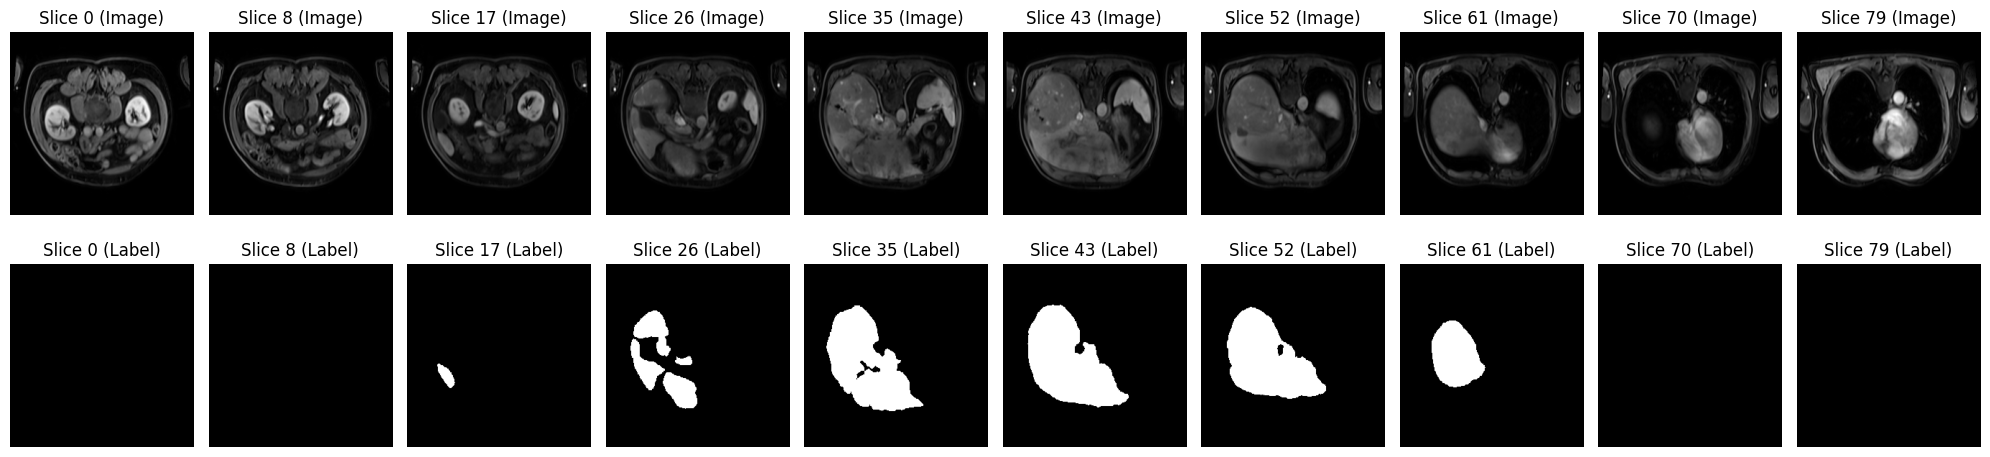

In [25]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Paths to image and label volumes
image_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/case_00001/imaging.nii.gz'
label_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/case_00001/segmentation.nii.gz'

# Load volumes
img_nii = nib.load(image_path)
lbl_nii = nib.load(label_path)

img_data = img_nii.get_fdata()
lbl_data = lbl_nii.get_fdata()

# Confirm shapes are (80, 256, 256)
assert img_data.shape == (80, 256, 256), f"Image volume shape unexpected: {img_data.shape}"
assert lbl_data.shape == (80, 256, 256), f"Label volume shape unexpected: {lbl_data.shape}"

# Select 10 slices evenly spaced from 0 to 79
num_slices = 10
slice_indices = np.linspace(0, img_data.shape[0]-1, num_slices, dtype=int)

# Plotting
fig, axes = plt.subplots(2, num_slices, figsize=(20, 5))

for i, idx in enumerate(slice_indices):
    # Image slice
    axes[0, i].imshow(img_data[idx, :, :].T, cmap='gray', origin='lower')
    axes[0, i].set_title(f"Slice {idx} (Image)")
    axes[0, i].axis('off')

    # Label slice (assuming discrete labels)
    axes[1, i].imshow(lbl_data[idx, :, :].T, cmap='gray', origin='lower')
    axes[1, i].set_title(f"Slice {idx} (Label)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


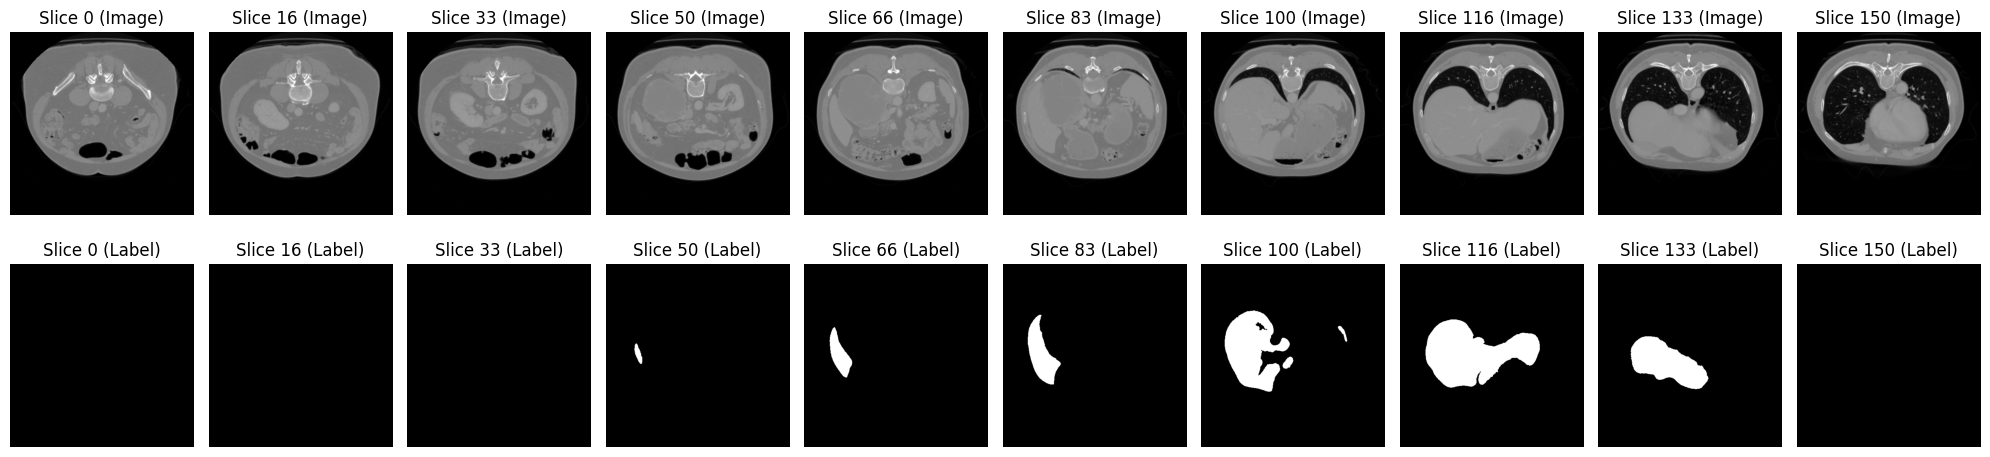

In [26]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import os

# Define folders
img_dir = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/ircad/3Dircadb1.7/PATIENT_DICOM'
lbl_dir = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/ircad/3Dircadb1.7/MASKS_DICOM/liver'

# Number of DICOM images
num_slices = 151  # image_0 to image_150

# Select 10 evenly spaced slice indices
num_to_plot = 10
slice_indices = np.linspace(0, num_slices-1, num_to_plot, dtype=int)

# Prepare plot
fig, axes = plt.subplots(2, num_to_plot, figsize=(20, 5))

for i, idx in enumerate(slice_indices):
    img_path = os.path.join(img_dir, f'image_{idx}')
    lbl_path = os.path.join(lbl_dir, f'image_{idx}')
    # Load image DICOM
    img_dcm = pydicom.dcmread(img_path)
    img_arr = img_dcm.pixel_array.astype(float)
    # Load label DICOM
    lbl_dcm = pydicom.dcmread(lbl_path)
    lbl_arr = lbl_dcm.pixel_array

    # First row: Image
    axes[0, i].imshow(img_arr, cmap='gray', origin='lower')
    axes[0, i].set_title(f'Slice {idx} (Image)')
    axes[0, i].axis('off')

    # Second row: Label/mask
    axes[1, i].imshow(lbl_arr, cmap='gray', origin='lower')
    axes[1, i].set_title(f'Slice {idx} (Label)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


0.0 1491.7577548138797
[1452.24159608 1489.68634327 1491.75775481] (80, 256, 256)
40


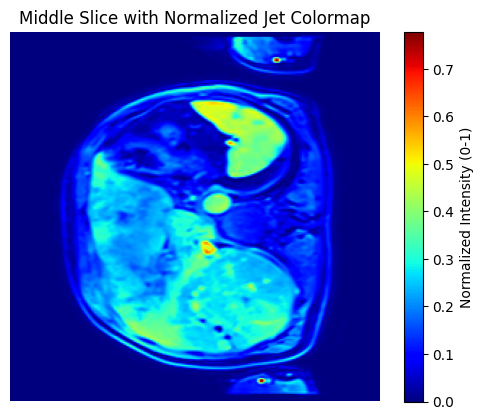

In [24]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Load the NIfTI file
nii_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/case_00001/imaging.nii.gz'
img = nib.load(nii_path)

data = img.get_fdata()
# data = (data - np.mean(data)) / np.std(data)
print(np.min(data), np.max(data))
print(np.unique(data)[-3:], data.shape)
# Get the middle slice index along the third dimension (usually axial)
mid_slice_idx = data.shape[0] // 2
mid_slice = data[mid_slice_idx, :, :]
print(mid_slice_idx)

# Plot the middle slice with jet colormap
min_val = 0.0
max_val = 1491.7577548138797
normalized_slice = np.clip((mid_slice - min_val) / (max_val - min_val), 0, 1)

# Plot normalized slice with jet colormap
plt.imshow(normalized_slice, cmap='jet', origin='lower')
plt.colorbar(label='Normalized Intensity (0-1)')
plt.title('Middle Slice with Normalized Jet Colormap')
plt.axis('off')
plt.show()


0.0 1.0
[0. 1.] (80, 256, 256)
40
Min value: 0.0
Max value: 1.0
Unique values: [0. 1.]


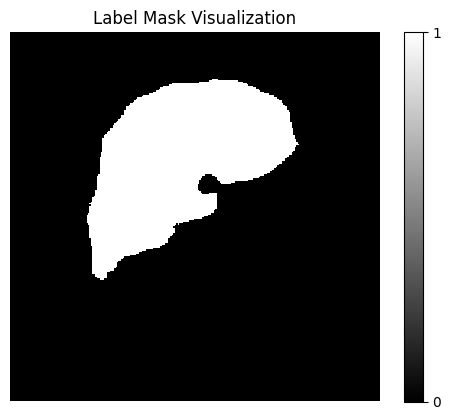

In [23]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Load the NIfTI file
nii_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/data/case_00001/segmentation.nii.gz'
img = nib.load(nii_path)

data = img.get_fdata()
# data = (data - np.mean(data)) / np.std(data)
print(np.min(data), np.max(data))
print(np.unique(data)[-3:], data.shape)
# Get the middle slice index along the third dimension (usually axial)
mid_slice_idx = data.shape[0] // 2
label_img = data[mid_slice_idx, :, :]
print(mid_slice_idx)
print(f"Min value: {label_img.min()}")
print(f"Max value: {label_img.max()}")
unique_vals = np.unique(label_img)
print(f"Unique values: {unique_vals}")

# Plot with discrete colormap for labels
plt.imshow(label_img, cmap='gray', interpolation='nearest')
plt.title('Label Mask Visualization')
plt.colorbar(ticks=unique_vals)
plt.axis('off')
plt.show()


Min value: -1023.0
Max value: 1024.0
Number of unique pixel values: 1933


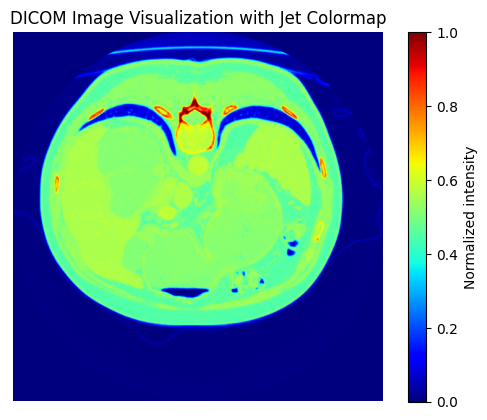

In [20]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# Path to your DICOM file
dicom_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/ircad/3Dircadb1.7/PATIENT_DICOM/image_91'

# Load DICOM file
ds = pydicom.dcmread(dicom_path)

# Extract pixel array
img = ds.pixel_array.astype(np.float32)

# Print min, max and unique values
min_val = img.min()
max_val = img.max()
unique_vals = np.unique(img)
print(f"Min value: {min_val}")
print(f"Max value: {max_val}")
print(f"Number of unique pixel values: {len(unique_vals)}")

# Normalize the image between 0 and 1 for visualization
norm_img = (img - min_val) / (max_val - min_val)

# Plot with jet colormap
plt.imshow(norm_img, cmap='jet', origin='lower')
plt.colorbar(label='Normalized intensity')
plt.title('DICOM Image Visualization with Jet Colormap')
plt.axis('off')
plt.show()


Min value: 0
Max value: 255
Unique values: [  0 255]


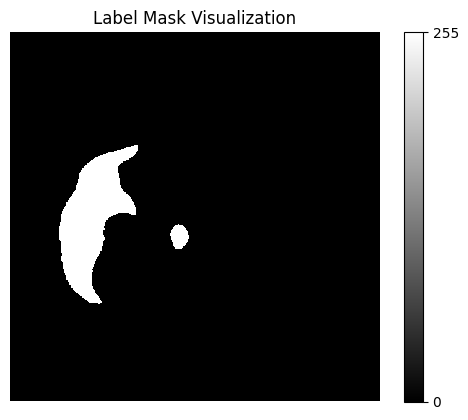

In [18]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt

label_path = '/mnt/e3dbc9b9-6856-470d-84b1-ff55921cd906/SFR_modeling/ircad/3Dircadb1.7/MASKS_DICOM/liver/image_91'

# Load DICOM label image
ds_label = pydicom.dcmread(label_path)
label_img = ds_label.pixel_array

# Print statistics
print(f"Min value: {label_img.min()}")
print(f"Max value: {label_img.max()}")
unique_vals = np.unique(label_img)
print(f"Unique values: {unique_vals}")

# Plot with discrete colormap for labels
plt.imshow(label_img, cmap='gray', interpolation='nearest')
plt.title('Label Mask Visualization')
plt.colorbar(ticks=unique_vals)
plt.axis('off')
plt.show()
